# EVRP-XAI: Explainable Deep Reinforcement Learning for Electric Vehicle Routing
## Combined & Enhanced Research Notebook

**Architecture:** Multi-Head GAT Encoder → Attention Decoder → A2C Policy  
**Study:** Distance-based vs Inverse-distance reward — how reward shapes learned policy  
**XAI:** Attention traces · Feature importance · Counterfactual state perturbation · Explanation metrics  
**LLM:** Per-step grounded decision reports (Groq / rule-based fallback)

---
| Section | Content |
|---------|---------|
| 0 | Setup & Config |
| 1 | Instance Generator & Environment |
| 2 | GAT Encoder + Attention Decoder |
| 3 | A2C Agent + Episode Runner |
| 4 | **Training** — Multi-seed, both reward modes |
| 5 | **Training Diagnostics** — 9-panel analysis |
| 6 | **Reward Mode Comparison** — normalised, fair scale |
| 7 | **Route Visualisation** — map + battery evolution |
| 8 | **XAI: Explanation Tracer** — attention & confidence |
| 9 | **XAI: Counterfactual Analyzer** — state perturbation |
| 10 | **XAI: Feature Importance** — logit ablation |
| 11 | **LLM Explanation Layer** — per-step reports |
| 12 | **Evaluation vs Baselines** — distance, feasibility, violations |
| 13 | **Ablation Study** — GAT vs MLP × Distance vs Inverse |
| 14 | **Final Dashboard** — publication-ready summary |

## 0 — Setup
All imports, seeds, device, output directory, and API keys.

In [1]:
import os, json, math, copy, random, warnings, time
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120,
                            'axes.spines.top': False, 'axes.spines.right': False})

# ── Reproducibility ──────────────────────────────────────────────────────────
SEEDS  = [42, 123, 777]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = Path('results_xai'); OUT.mkdir(exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

# ── Problem config ───────────────────────────────────────────────────────────
N_CUSTOMERS   = 15        # problem size
CHARGER_PROB  = 0.15      # fraction of nodes that become chargers
CARGO_CAP     = 30.0
BATTERY_CAP   = 100.0
N_EPISODES    = 800       # episodes per seed
EMBED_DIM     = 128
N_HEADS       = 8
N_LAYERS      = 3
LR            = 3e-4
ENTROPY_COEF  = 0.01
GAMMA         = 0.99

# ── LLM config ───────────────────────────────────────────────────────────────
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')   # set env var or paste here
GROQ_MODEL   = 'llama3-8b-8192'
LLM_ENABLED  = bool(GROQ_API_KEY)

print(f'Device : {DEVICE}')
print(f'Problem: EVRP-{N_CUSTOMERS} | cargo={CARGO_CAP} | battery={BATTERY_CAP}')
print(f'LLM    : {"Groq (" + GROQ_MODEL + ")" if LLM_ENABLED else "rule-based fallback"}')

Device : cpu
Problem: EVRP-15 | cargo=30.0 | battery=100.0
LLM    : Groq (llama3-8b-8192)


## 1 — Instance Generator & Environment
**Design decisions (fixes applied):**
- Depot recharges battery AND cargo → prevents infinite depot-loop
- Customer service bonus `+0.2` + completion bonus `+2.0` → clear learning signal
- Battery/cargo violation penalties → model learns hard constraints
- Full metrics tracking: charger visits, violations, masked actions

In [2]:
def generate_instance(n_customers: int = 15, seed: int = None,
                       charger_prob: float = 0.15) -> dict:
    rng = np.random.RandomState(seed)
    n_total = n_customers + 1                    # +1 depot at index 0
    coords   = rng.uniform(0, 1, (n_total, 2)).astype(np.float32)
    demands  = np.zeros(n_total, dtype=np.float32)
    demands[1:] = rng.randint(1, 8, n_customers).astype(np.float32)
    node_types = np.zeros(n_total, dtype=int)    # 0=depot
    node_types[1:] = 1                           # customers
    chargers = rng.rand(n_customers) < charger_prob
    node_types[1:][chargers] = 2                 # some become chargers
    demands[node_types == 2] = 0                 # chargers: no demand
    return dict(coords=coords, demands=demands, node_types=node_types,
                cargo_cap=CARGO_CAP, battery_cap=BATTERY_CAP,
                n_nodes=n_total)

def build_node_features(inst: dict) -> torch.Tensor:
    """7-dim: [x, y, demand_norm, is_charger, is_depot, cargo_cap_norm, battery_cap_norm]"""
    n = inst['n_nodes']
    f = np.zeros((n, 7), dtype=np.float32)
    f[:, 0] = inst['coords'][:, 0]
    f[:, 1] = inst['coords'][:, 1]
    f[:, 2] = inst['demands'] / inst['cargo_cap']
    f[:, 3] = (inst['node_types'] == 2).astype(float)
    f[:, 4] = (inst['node_types'] == 0).astype(float)
    f[:, 5] = inst['cargo_cap']    / 50.0
    f[:, 6] = inst['battery_cap']  / 200.0
    return torch.FloatTensor(f)

def make_dataset(n: int, n_customers: int = 15, seed0: int = 0) -> list:
    return [generate_instance(n_customers, seed=seed0 + i) for i in range(n)]

print(f'✓ Instance generator ready')
demo = generate_instance(N_CUSTOMERS, seed=42)
print(f'  nodes={demo["n_nodes"]}  chargers={(demo["node_types"]==2).sum()}  customers={(demo["node_types"]==1).sum()}')

✓ Instance generator ready
  nodes=16  chargers=1  customers=14


In [3]:
class EVRPEnv:
    """EVRP environment with proper battery recharge at depot."""

    def __init__(self, inst: dict, reward_mode: str = 'distance'):
        self.inst        = inst
        self.reward_mode = reward_mode
        self.n           = inst['n_nodes']
        self.coords      = inst['coords']
        self.demands     = inst['demands'].copy()
        self.types       = inst['node_types']
        self.cargo_cap   = inst['cargo_cap']
        self.battery_cap = inst['battery_cap']
        self.D           = self._build_dist()
        self.d_max       = self.D.max() + 1e-9

    def _build_dist(self) -> np.ndarray:
        c = self.coords
        diff = c[:, None] - c[None, :]
        return np.sqrt((diff**2).sum(-1)).astype(np.float32)

    def reset(self):
        self.cur      = 0
        self.battery  = self.battery_cap
        self.cargo    = self.cargo_cap
        self.visited  = np.zeros(self.n, dtype=bool)
        self.visited[0] = True
        self.done     = False
        self.route    = [0]
        self.total_d  = 0.0
        self.steps    = 0
        # diagnostic logs
        self.battery_log     = [self.battery]
        self.charger_visits  = 0
        self.batt_violations = 0
        self.cargo_violations= 0
        self.masked_counts   = []
        return self._obs()

    def _obs(self) -> dict:
        return dict(
            node_features = build_node_features(self.inst),
            current_node  = self.cur,
            battery_norm  = np.float32(self.battery / self.battery_cap),
            cargo_norm    = np.float32(self.cargo  / self.cargo_cap),
            visited_mask  = self.visited.copy(),
            valid_mask    = self._valid_mask(),
        )

    def _valid_mask(self) -> np.ndarray:
        """True = can visit this node."""
        valid = np.zeros(self.n, dtype=bool)
        for j in range(self.n):
            if j == self.cur: continue
            d_to_j = self.D[self.cur, j]
            if self.battery < d_to_j: continue          # battery check
            if self.types[j] == 2:                      # charger: always ok if reachable
                valid[j] = True; continue
            if j == 0:                                  # depot: always ok
                valid[j] = True; continue
            d_back = self.D[j, 0]
            if (not self.visited[j]) and self.cargo >= self.demands[j]:
                if self.battery >= d_to_j + d_back:    # can reach & return
                    valid[j] = True
        if not valid.any():
            valid[0] = True
        self.masked_counts.append(int((~valid).sum()))
        return valid

    def step(self, action: int) -> Tuple[dict, float, bool, dict]:
        d = self.D[self.cur, action]
        self.battery  -= d
        self.total_d  += d
        self.steps    += 1

        batt_viol = self.battery < -1e-3
        if batt_viol: self.batt_violations += 1

        # Reward
        if self.reward_mode == 'distance':
            reward = -float(d) / self.d_max
        else:
            reward = 0.4 / (float(d) / self.d_max + 0.05)

        served_now = False
        if self.types[action] == 2:              # charger
            self.battery = self.battery_cap
            self.charger_visits += 1
            reward -= 0.05
        elif action == 0:                        # depot — KEY FIX: recharge both
            self.battery = self.battery_cap
            self.cargo   = self.cargo_cap
            if not self.visited[1:].all():
                reward -= 0.3                    # early return penalty
        else:                                    # customer
            cargo_viol = self.cargo < self.demands[action]
            if cargo_viol: self.cargo_violations += 1
            self.cargo  -= self.demands[action]
            self.visited[action] = True
            served_now = True
            reward += 0.2                        # service bonus

        self.cur = action
        self.route.append(action)
        self.battery_log.append(max(0.0, self.battery))

        customers = np.where(self.types == 1)[0]
        all_served = self.visited[customers].all()

        if all_served and action == 0:
            reward += 2.0                        # completion bonus
        if batt_viol: reward -= 1.0

        self.done = (all_served and action == 0) or self.steps >= 4 * self.n

        info = dict(
            dist=float(d), total_dist=self.total_d,
            all_served=bool(all_served),
            n_customers_served=int(self.visited[customers].sum()),
            battery=max(0.0, self.battery), cargo=self.cargo,
            charger_visits=self.charger_visits,
            batt_violations=self.batt_violations,
            cargo_violations=self.cargo_violations,
            node_type=int(self.types[action]),
        )
        return self._obs(), reward, self.done, info

print('✓ EVRPEnv ready')

✓ EVRPEnv ready


## 2 — Model: Multi-Head GAT Encoder + Attention Decoder
**Architecture from Notebook 2 (production-grade):**
- `MultiHeadAttention` with proper `nan_to_num` guard
- `GATEncoderLayer` = attention + FFN + LayerNorm (transformer-style)
- `EVRPDecoder`: context query (current node + battery + cargo) cross-attends to node embeddings
- Logits = dot product of attended context with all node embeddings

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, input_dim, embed_dim):
        super().__init__()
        self.n_heads     = n_heads
        self.head_dim    = embed_dim // n_heads
        self.norm_factor = 1.0 / math.sqrt(self.head_dim)
        self.W_q = nn.Linear(input_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(input_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(input_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, q, k=None, v=None, mask=None, return_attn=False):
        if k is None: k = q
        if v is None: v = k
        B, Tq, _ = q.shape; _, Tk, _ = k.shape
        H, D     = self.n_heads, self.head_dim
        Q = self.W_q(q).view(B,Tq,H,D).transpose(1,2)
        K = self.W_k(k).view(B,Tk,H,D).transpose(1,2)
        V = self.W_v(v).view(B,Tk,H,D).transpose(1,2)
        sc = self.norm_factor * torch.matmul(Q, K.transpose(-2,-1))
        if mask is not None:
            m = mask.unsqueeze(1).unsqueeze(2).expand_as(sc)
            sc = sc.masked_fill(m, float('-inf'))
        attn = torch.nan_to_num(torch.softmax(sc, dim=-1), nan=0.0)
        out  = self.W_o(torch.matmul(attn,V).transpose(1,2).contiguous().view(B,Tq,H*D))
        return (out, attn) if return_attn else out


class GATEncoderLayer(nn.Module):
    def __init__(self, embed_dim, n_heads, ff_dim=256):
        super().__init__()
        self.attn  = MultiHeadAttention(n_heads, embed_dim, embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(),
                                   nn.Linear(ff_dim, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x


class EVRPEncoder(nn.Module):
    def __init__(self, input_dim=7, embed_dim=128, n_heads=8, n_layers=3, enc_type='gat'):
        super().__init__()
        self.embed  = nn.Linear(input_dim, embed_dim)
        if enc_type == 'gat':
            self.layers = nn.ModuleList([GATEncoderLayer(embed_dim, n_heads) for _ in range(n_layers)])
        else:
            self.layers = nn.ModuleList([
                nn.Sequential(nn.Linear(embed_dim,embed_dim), nn.GELU(), nn.LayerNorm(embed_dim))
                for _ in range(n_layers)])
        self.last_attn = None   # stored for XAI

    def forward(self, x):       # x: (B,n,7)
        h = self.embed(x)
        for i, layer in enumerate(self.layers):
            if isinstance(layer, GATEncoderLayer):
                # Store attention from last GAT layer for XAI
                if i == len(self.layers)-1:
                    out, attn = layer.attn(h, return_attn=True)
                    self.last_attn = attn.detach()
                    h = layer.norm1(h + out)
                    h = layer.norm2(h + layer.ff(h))
                else:
                    h = layer(h)
            else:
                h = layer(h)
        return h, h.mean(dim=1)   # (B,n,D), (B,D)


class EVRPDecoder(nn.Module):
    def __init__(self, embed_dim=128, n_heads=8):
        super().__init__()
        self.proj_ctx  = nn.Linear(embed_dim + 2, embed_dim)
        self.cross_attn= MultiHeadAttention(n_heads, embed_dim, embed_dim)
    def forward(self, node_emb, graph_emb, battery_norm, cargo_norm,
                cur_node_idx, invalid_mask=None, return_attn=False):
        B, n, D = node_emb.shape
        idx     = cur_node_idx.long().view(B,1,1).expand(B,1,D)
        cur_emb = node_emb.gather(1, idx).squeeze(1)
        ctx     = self.proj_ctx(torch.cat([cur_emb, battery_norm, cargo_norm], -1)).unsqueeze(1)
        if return_attn:
            attended, attn = self.cross_attn(ctx, node_emb, node_emb,
                                              mask=invalid_mask, return_attn=True)
        else:
            attended = self.cross_attn(ctx, node_emb, node_emb, mask=invalid_mask)
            attn = None
        scores = (attended * node_emb).sum(-1)   # (B,n)
        if invalid_mask is not None:
            scores = scores.masked_fill(invalid_mask, float('-inf'))
        return (scores, attn) if return_attn else scores

print('✓ Encoder & Decoder ready')

✓ Encoder & Decoder ready


## 3 — A2C Agent + Episode Runner

In [5]:
class A2CAgent(nn.Module):
    def __init__(self, embed_dim=128, n_heads=8, n_layers=3,
                 lr=3e-4, gamma=0.99, entropy_coef=0.01, value_coef=0.5,
                 enc_type='gat'):
        super().__init__()
        self.gamma      = gamma
        self.ent_coef   = entropy_coef
        self.val_coef   = value_coef
        self.encoder    = EVRPEncoder(7, embed_dim, n_heads, n_layers, enc_type)
        self.decoder    = EVRPDecoder(embed_dim, n_heads)
        self.value_head = nn.Sequential(nn.Linear(embed_dim,64), nn.GELU(), nn.Linear(64,1))
        self.optimizer  = torch.optim.Adam(self.parameters(), lr=lr, eps=1e-5)
        self.scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=N_EPISODES, eta_min=lr/10)

    def _forward(self, obs, return_attn=False):
        feats   = obs['node_features'].unsqueeze(0).to(DEVICE)
        bat_t   = torch.FloatTensor([[obs['battery_norm']]]).to(DEVICE)
        car_t   = torch.FloatTensor([[obs['cargo_norm']]]).to(DEVICE)
        cur_t   = torch.LongTensor([obs['current_node']]).to(DEVICE)
        inv_t   = torch.BoolTensor(~obs['valid_mask']).unsqueeze(0).to(DEVICE)
        node_emb, graph_emb = self.encoder(feats)
        if return_attn:
            scores, attn = self.decoder(node_emb, graph_emb, bat_t, car_t, cur_t, inv_t, return_attn=True)
            val = self.value_head(graph_emb)
            return scores, val, node_emb, attn, self.encoder.last_attn
        scores = self.decoder(node_emb, graph_emb, bat_t, car_t, cur_t, inv_t)
        val    = self.value_head(graph_emb)
        return scores, val, node_emb

    def select_action(self, obs, greedy=False):
        scores, val, node_emb = self._forward(obs)
        dist   = Categorical(logits=scores.squeeze(0))
        action = dist.probs.argmax().item() if greedy else dist.sample().item()
        return action, dist.log_prob(torch.tensor(action)), dist.entropy(), val

    def update(self, transitions):
        rewards   = [t['r'] for t in transitions]
        log_probs = torch.stack([t['lp'] for t in transitions])
        entropies = torch.stack([t['ent'] for t in transitions])
        values    = torch.stack([t['val'].squeeze() for t in transitions])
        R = 0.0; rets = []
        for r in reversed(rewards):
            R = r + self.gamma * R; rets.insert(0, R)
        rets = torch.FloatTensor(rets).to(DEVICE)
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)
        adv  = rets - values.detach()
        loss = (-(log_probs * adv).mean()
                + self.val_coef * F.mse_loss(values, rets)
                - self.ent_coef * entropies.mean())
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.parameters(), 1.0)
        self.optimizer.step()
        self.scheduler.step()
        return float(loss.item()), float(entropies.mean().item())


def run_episode(agent, inst, greedy=False, collect_traces=False,
                bat_perturb=None, cargo_perturb=None):
    env    = EVRPEnv(inst, reward_mode=inst.get('reward_mode', 'distance'))
    obs    = env.reset()
    done   = False; total_r = 0.0
    transitions = []; traces = [] if collect_traces else None

    while not done:
        # Apply state perturbations (for counterfactual analysis)
        obs_use = obs
        if bat_perturb is not None or cargo_perturb is not None:
            obs_use = dict(obs)
            if bat_perturb   is not None:
                obs_use['battery_norm'] = float(np.clip(obs['battery_norm'] * bat_perturb, 0, 1))
            if cargo_perturb is not None:
                obs_use['cargo_norm']   = float(np.clip(obs['cargo_norm']   * cargo_perturb, 0, 1))

        with torch.no_grad():
            action, lp, ent, val = agent.select_action(obs_use, greedy=greedy)

        if collect_traces:
            scores, _, _, dec_attn, enc_attn = agent._forward(obs_use, return_attn=True)
            probs = torch.softmax(scores.squeeze(0), -1)
            # Average attention over heads: (B,H,1,n) -> (n,)
            attn_avg = dec_attn[0].mean(0).squeeze(0).cpu().numpy() if dec_attn is not None else np.zeros(env.n)
            # Encoder self-attention: (B,H,n,n) -> mean over heads, current node row
            enc_attn_row = (enc_attn[0].mean(0)[obs['current_node']].cpu().numpy()
                            if enc_attn is not None else np.zeros(env.n))
            top3_p, top3_n = probs.topk(min(3, probs.shape[0]))
            traces.append(dict(
                step=len(traces), from_node=int(obs['current_node']), to_node=int(action),
                node_type=int(inst['node_types'][action]),
                battery_norm=float(obs['battery_norm']), cargo_norm=float(obs['cargo_norm']),
                battery_abs=float(obs['battery_norm'] * inst['battery_cap']),
                cargo_abs=float(obs['cargo_norm'] * inst['cargo_cap']),
                action_prob=float(probs[action].item()),
                action_logit=float(scores.squeeze(0)[action].item()),
                raw_logits=scores.squeeze(0).cpu().detach().numpy().tolist(),
                top3_nodes=top3_n.tolist(), top3_probs=top3_p.tolist(),
                valid_mask=obs['valid_mask'].tolist(),
                invalid_count=int((~obs['valid_mask']).sum()),
                dec_attn=attn_avg.tolist(),
                enc_attn=enc_attn_row.tolist(),
                dist_to_action=float(env.D[obs['current_node'], action]),
                dist_to_depot=float(env.D[action, 0]),
                is_charger=int(inst['node_types'][action] == 2),
                is_depot=int(action == 0),
                is_forced=int(np.sum(obs['valid_mask']) <= 1),
            ))

        next_obs, r, done, info = env.step(action)
        total_r += r
        transitions.append(dict(r=r, lp=lp, ent=ent, val=val))
        obs = next_obs

    return total_r, env.route, env.total_d, info, transitions, traces, env

print('✓ A2CAgent & run_episode ready')

✓ A2CAgent & run_episode ready


## 4 — Training: Both Reward Modes × 3 Seeds
Training configuration:
- **800 episodes** per run | cosine LR annealing | grad clip 1.0
- **Distance mode**: `reward = −dist / d_max` → minimise total route length
- **Inverse mode**: `reward = 0.4 / (dist/d_max + 0.05)` → strongly rewards short hops
- 200 training instances rotated per episode
- Evaluation every 100 episodes on held-out set

In [6]:
def run_episode(agent, inst, greedy=False, collect_traces=False,
                bat_perturb=None, cargo_perturb=None):
    env    = EVRPEnv(inst, reward_mode=inst.get('reward_mode', 'distance'))
    obs    = env.reset()
    done   = False; total_r = 0.0
    transitions = []; traces = [] if collect_traces else None

    while not done:
        obs_use = obs
        if bat_perturb is not None or cargo_perturb is not None:
            obs_use = dict(obs)
            if bat_perturb   is not None:
                obs_use['battery_norm'] = float(np.clip(obs['battery_norm'] * bat_perturb, 0, 1))
            if cargo_perturb is not None:
                obs_use['cargo_norm']   = float(np.clip(obs['cargo_norm']   * cargo_perturb, 0, 1))

        # ── FIX: only disable gradients during greedy/eval episodes ──────────
        if greedy:
            with torch.no_grad():
                action, lp, ent, val = agent.select_action(obs_use, greedy=True)
        else:
            action, lp, ent, val = agent.select_action(obs_use, greedy=False)
        # ─────────────────────────────────────────────────────────────────────

        if collect_traces:
            with torch.no_grad():
                scores, _, _, dec_attn, enc_attn = agent._forward(obs_use, return_attn=True)
            probs = torch.softmax(scores.squeeze(0), -1)
            attn_avg = dec_attn[0].mean(0).squeeze(0).cpu().numpy() if dec_attn is not None else np.zeros(env.n)
            enc_attn_row = (enc_attn[0].mean(0)[obs['current_node']].cpu().numpy()
                            if enc_attn is not None else np.zeros(env.n))
            top3_p, top3_n = probs.topk(min(3, probs.shape[0]))
            traces.append(dict(
                step=len(traces), from_node=int(obs['current_node']), to_node=int(action),
                node_type=int(inst['node_types'][action]),
                battery_norm=float(obs['battery_norm']), cargo_norm=float(obs['cargo_norm']),
                battery_abs=float(obs['battery_norm'] * inst['battery_cap']),
                cargo_abs=float(obs['cargo_norm'] * inst['cargo_cap']),
                action_prob=float(probs[action].item()),
                action_logit=float(scores.squeeze(0)[action].item()),
                raw_logits=scores.squeeze(0).cpu().detach().numpy().tolist(),
                top3_nodes=top3_n.tolist(), top3_probs=top3_p.tolist(),
                valid_mask=obs['valid_mask'].tolist(),
                invalid_count=int((~obs['valid_mask']).sum()),
                dec_attn=attn_avg.tolist(),
                enc_attn=enc_attn_row.tolist(),
                dist_to_action=float(env.D[obs['current_node'], action]),
                dist_to_depot=float(env.D[action, 0]),
                is_charger=int(inst['node_types'][action] == 2),
                is_depot=int(action == 0),
                is_forced=int(np.sum(obs['valid_mask']) <= 1),
            ))

        next_obs, r, done, info = env.step(action)
        total_r += r
        transitions.append(dict(r=r, lp=lp, ent=ent, val=val))
        obs = next_obs

    return total_r, env.route, env.total_d, info, transitions, traces, env


def train_agent(reward_mode='distance', enc_type='gat',
                n_episodes=N_EPISODES, seed=42, verbose_every=100):
    set_seed(seed)
    agent = A2CAgent(embed_dim=EMBED_DIM, n_heads=N_HEADS, n_layers=N_LAYERS,
                     lr=LR, gamma=GAMMA, entropy_coef=ENTROPY_COEF,
                     enc_type=enc_type).to(DEVICE)

    train_data = [dict(inst, reward_mode=reward_mode)
                  for inst in make_dataset(200, N_CUSTOMERS, seed * 1000)]
    eval_data  = [dict(inst, reward_mode=reward_mode)
                  for inst in make_dataset(30,  N_CUSTOMERS, seed * 1000 + 9999)]

    hist = dict(reward=[], loss=[], entropy=[], feasibility=[],
                eval_dist=[], eval_feas=[], customers_served=[], charger_visits=[])
    best_eval, best_w = float('inf'), None

    for ep in range(1, n_episodes + 1):
        inst = train_data[ep % len(train_data)]
        total_r, route, dist, info, transitions, _, env = run_episode(agent, inst)
        loss, ent = agent.update(transitions)

        hist['reward'].append(float(total_r))
        hist['loss'].append(float(loss))
        hist['entropy'].append(float(ent))
        hist['feasibility'].append(int(info['all_served']))
        hist['customers_served'].append(int(info['n_customers_served']))
        hist['charger_visits'].append(int(info['charger_visits']))

        if ep % verbose_every == 0:
            ed, ef = [], []
            with torch.no_grad():
                for einst in eval_data:
                    _, _, edist, einfo, _, _, _ = run_episode(agent, einst, greedy=True)
                    ed.append(edist); ef.append(float(einfo['all_served']))
            hist['eval_dist'].append(float(np.mean(ed)))
            hist['eval_feas'].append(float(np.mean(ef)))
            if np.mean(ed) < best_eval:
                best_eval = np.mean(ed)
                best_w    = copy.deepcopy(agent.state_dict())
            print(f'  ep={ep:4d}  r={total_r:.2f}  eval_dist={np.mean(ed):.3f}  feas={np.mean(ef):.1%}')

    if best_w: agent.load_state_dict(best_w)
    return agent, hist


# ── RUN ALL TRAINING ─────────────────────────────────────────────────────────
print('Starting training...\n')
RESULTS = {}
for mode in ['distance', 'inverse']:
    RESULTS[mode] = {}
    for seed in SEEDS:
        print(f'[mode={mode}  seed={seed}]')
        agent, hist = train_agent(reward_mode=mode, seed=seed)
        RESULTS[mode][seed] = {'agent': agent, 'hist': hist}
print('\nAll training complete ✓')

Starting training...

[mode=distance  seed=42]
  ep= 100  r=-2.31  eval_dist=6.387  feas=100.0%
  ep= 200  r=-3.58  eval_dist=6.060  feas=100.0%
  ep= 300  r=-2.44  eval_dist=6.251  feas=100.0%
  ep= 400  r=-3.72  eval_dist=6.422  feas=100.0%
  ep= 500  r=-2.51  eval_dist=7.542  feas=100.0%
  ep= 600  r=-2.16  eval_dist=6.131  feas=100.0%
  ep= 700  r=-2.39  eval_dist=6.105  feas=100.0%
  ep= 800  r=-2.70  eval_dist=6.034  feas=100.0%
[mode=distance  seed=123]
  ep= 100  r=-0.82  eval_dist=6.700  feas=100.0%
  ep= 200  r=-3.68  eval_dist=6.021  feas=100.0%
  ep= 300  r=-0.28  eval_dist=6.223  feas=100.0%
  ep= 400  r=-3.20  eval_dist=6.730  feas=100.0%
  ep= 500  r=-1.07  eval_dist=6.587  feas=100.0%
  ep= 600  r=-3.29  eval_dist=6.388  feas=100.0%
  ep= 700  r=-1.70  eval_dist=6.506  feas=100.0%
  ep= 800  r=-5.36  eval_dist=6.635  feas=100.0%
[mode=distance  seed=777]
  ep= 100  r=-3.48  eval_dist=6.491  feas=100.0%
  ep= 200  r=-3.54  eval_dist=8.301  feas=96.7%
  ep= 300  r=-1.02  

## 5 — Training Diagnostics
**9-panel analysis covering:**
- Reward convergence with seed variance (± 1σ band)
- Moving average (50-ep) for trend clarity
- Policy entropy decay (should decrease as policy sharpens)
- Feasibility rate (rolling 30-ep)
- Loss curve
- Action confidence over time
- Customers served per episode
- Convergence stability (rolling std of reward)
- Seed variance scatter (final performance per seed)

✓ RESULTS validated — all modes and seeds present.


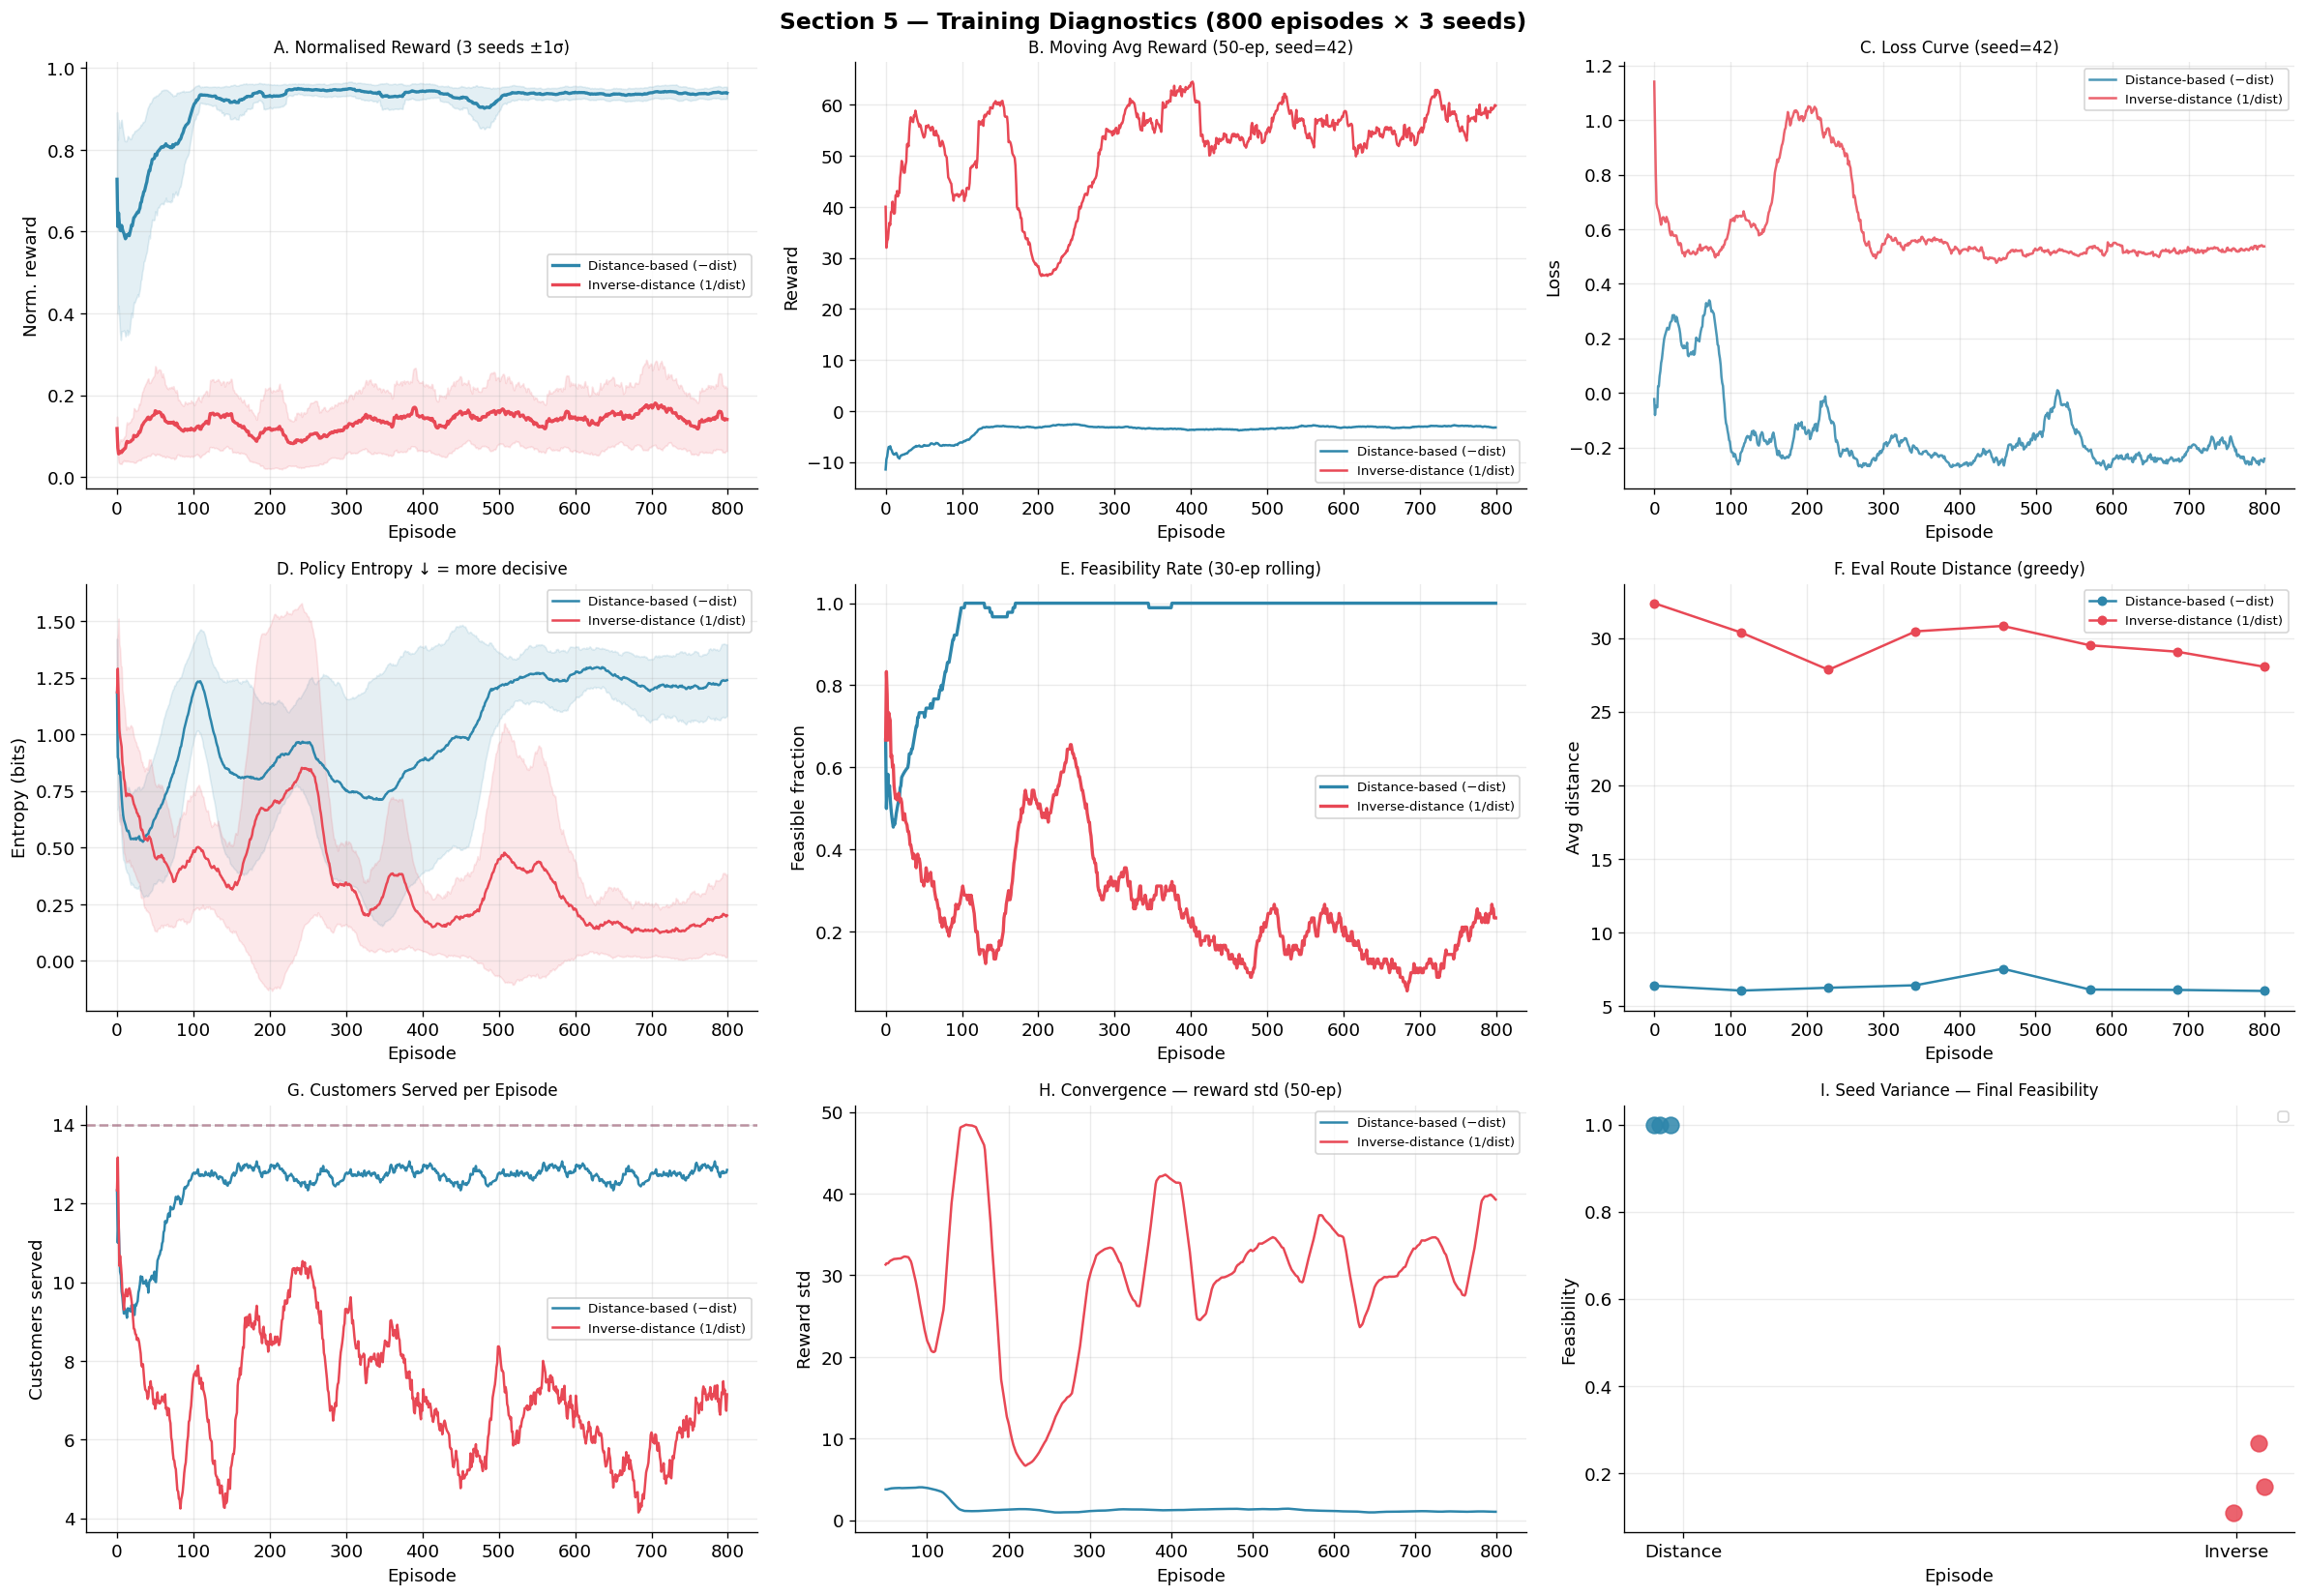

In [7]:
def smooth(x, w=30):
    return pd.Series(x, dtype=float).rolling(w, min_periods=1).mean().values

COLS = {'distance': '#2E86AB', 'inverse': '#E84855'}
LABS = {'distance': 'Distance-based (−dist)', 'inverse': 'Inverse-distance (1/dist)'}

# ── Sanity check ──────────────────────────────────────────────────────────────
assert 'RESULTS' in globals(), \
    "RESULTS not defined — re-run the training cell (Section 4) first."
for _mode in ['distance', 'inverse']:
    assert _mode in RESULTS, \
        f"Mode '{_mode}' missing from RESULTS — training cell may not have run."
    for _s in SEEDS:
        assert _s in RESULTS[_mode], (
            f"Seed {_s} missing under mode '{_mode}'. "
            f"Found seeds: {list(RESULTS[_mode].keys())}. "
            f"Training was likely interrupted — re-run Section 4 fully."
        )
print("✓ RESULTS validated — all modes and seeds present.")

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('Section 5 — Training Diagnostics (800 episodes × 3 seeds)',
             fontsize=14, fontweight='bold')

for mode, col in COLS.items():
    all_r   = [np.array(RESULTS[mode][s]['hist']['reward'],         dtype=float) for s in SEEDS]
    all_f   = [np.array(RESULTS[mode][s]['hist']['feasibility'],    dtype=float) for s in SEEDS]
    all_e   = [np.array(RESULTS[mode][s]['hist']['entropy'],        dtype=float) for s in SEEDS]
    all_loss= [np.array(RESULTS[mode][s]['hist']['loss'],           dtype=float) for s in SEEDS]
    all_cu  = [np.array(RESULTS[mode][s]['hist']['customers_served'],dtype=float) for s in SEEDS]
    h42     = RESULTS[mode][42]['hist']
    x       = np.arange(N_EPISODES)

    # Normalise rewards for fair cross-mode comparison
    concat_r = np.concatenate(all_r)
    mn_raw, mx_raw = concat_r.min(), concat_r.max()
    all_nr   = [(r - mn_raw) / (mx_raw - mn_raw + 1e-9) for r in all_r]

    mn_nr, sd_nr = np.mean(all_nr, 0), np.std(all_nr, 0)
    mn_f         = np.mean(all_f,  0)
    mn_e         = np.mean(all_e,  0); sd_e = np.std(all_e, 0)
    mn_cu        = np.mean(all_cu, 0)

    axes[0,0].plot(smooth(mn_nr), color=col, label=LABS[mode], lw=2)
    axes[0,0].fill_between(x, smooth(mn_nr - sd_nr), smooth(mn_nr + sd_nr),
                           alpha=0.13, color=col)

    axes[0,1].plot(smooth(np.array(h42['reward'], dtype=float), 50),
                   color=col, label=LABS[mode])

    axes[0,2].plot(smooth(np.array(h42['loss'], dtype=float), 20),
                   color=col, label=LABS[mode], alpha=0.85)

    axes[1,0].plot(smooth(mn_e), color=col, label=LABS[mode])
    axes[1,0].fill_between(x, smooth(mn_e - sd_e), smooth(mn_e + sd_e),
                           alpha=0.12, color=col)

    axes[1,1].plot(smooth(mn_f, 30), color=col, label=LABS[mode], lw=2)

    # Eval distance (logged every verbose_every episodes)
    ev_x = np.linspace(0, N_EPISODES, len(h42['eval_dist']))
    axes[1,2].plot(ev_x, h42['eval_dist'], 'o-', color=col,
                   label=LABS[mode], markersize=5)

    axes[2,0].plot(smooth(mn_cu, 20), color=col, label=LABS[mode])
    axes[2,0].axhline((demo['node_types'] == 1).sum(),
                      color=col, ls='--', alpha=0.4)

    conv_std = pd.Series(h42['reward']).rolling(50).std().values
    axes[2,1].plot(smooth(conv_std, 20), color=col, label=LABS[mode])

    for si, s in enumerate(SEEDS):
        jit = np.random.uniform(-0.06, 0.06)
        val = np.mean(RESULTS[mode][s]['hist']['feasibility'][-100:])
        axes[2,2].scatter({'distance': 0, 'inverse': 1}[mode] + jit, val,
                          color=col, s=100, alpha=0.85, zorder=5)

cfg = [
    (axes[0,0], 'A. Normalised Reward (3 seeds ±1σ)',    'Norm. reward'),
    (axes[0,1], 'B. Moving Avg Reward (50-ep, seed=42)', 'Reward'),
    (axes[0,2], 'C. Loss Curve (seed=42)',               'Loss'),
    (axes[1,0], 'D. Policy Entropy ↓ = more decisive',   'Entropy (bits)'),
    (axes[1,1], 'E. Feasibility Rate (30-ep rolling)',   'Feasible fraction'),
    (axes[1,2], 'F. Eval Route Distance (greedy)',       'Avg distance'),
    (axes[2,0], 'G. Customers Served per Episode',       'Customers served'),
    (axes[2,1], 'H. Convergence — reward std (50-ep)',   'Reward std'),
    (axes[2,2], 'I. Seed Variance — Final Feasibility',  'Feasibility'),
]
for ax, title, ylabel in cfg:
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Episode')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

axes[2,2].set_xticks([0, 1])
axes[2,2].set_xticklabels(['Distance', 'Inverse'])
plt.tight_layout()
plt.savefig(OUT / 'fig_training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Reward Mode Comparison
**Why this comparison matters:**  
Distance reward and inverse-distance reward operate on completely different scales
(negative vs positive). We compare them on **shared metrics**:
- Normalised reward (both to [0,1])
- Route distance (lower = better)
- Feasibility rate (higher = better)
- Attention heatmaps side-by-side
- Decision entropy: does reward mode affect decision confidence?

distance: steps=16  dist=6.310  served=14  chargers=0
inverse: steps=64  dist=36.153  served=6  chargers=32


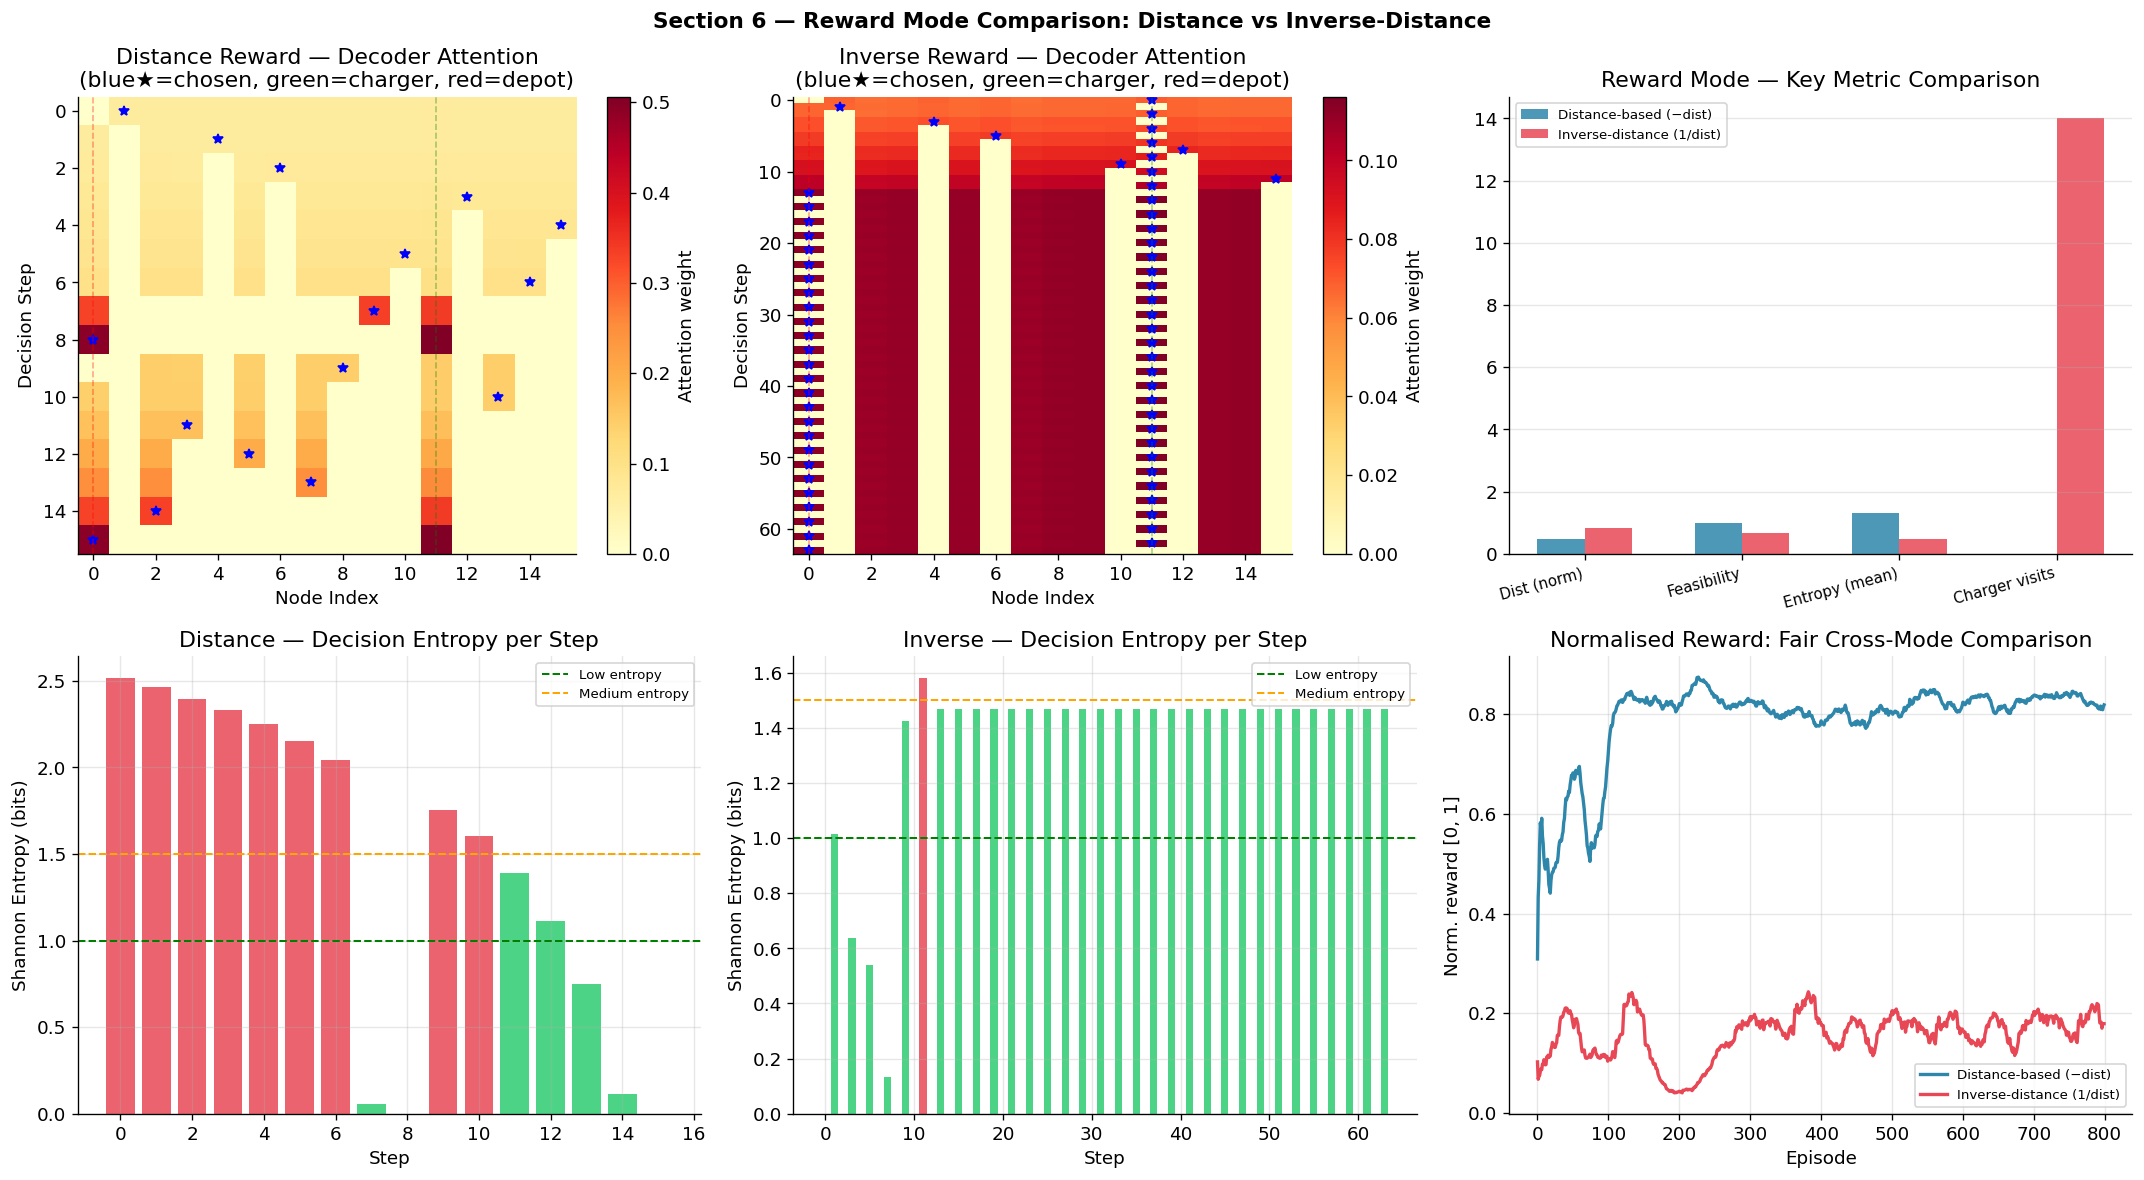

In [8]:
# ── Collect greedy episode traces for both modes ─────────────────────────────
REF_INST = dict(generate_instance(N_CUSTOMERS, seed=42), reward_mode='distance')
TRACES   = {}
for mode in ['distance', 'inverse']:
    inst_m = dict(generate_instance(N_CUSTOMERS, seed=42), reward_mode=mode)
    agent  = RESULTS[mode][42]['agent']
    with torch.no_grad():
        _, route, dist, info, _, traces, env = run_episode(
            agent, inst_m, greedy=True, collect_traces=True)
    TRACES[mode] = dict(traces=traces, route=route, dist=dist,
                        info=info, env=env, inst=inst_m)
    print(f'{mode}: steps={len(traces)}  dist={dist:.3f}'
          f'  served={info["n_customers_served"]}  chargers={info["charger_visits"]}')

# ── Comparison figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Section 6 — Reward Mode Comparison: Distance vs Inverse-Distance',
             fontsize=13, fontweight='bold')

for ci, mode in enumerate(['distance', 'inverse']):
    tr  = TRACES[mode]['traces']
    env = TRACES[mode]['env']

    # ── Attention heatmap ─────────────────────────────────────────────────────
    ax = axes[0, ci]
    am = np.array([t['dec_attn'] for t in tr])
    if am.shape[0] > 0 and am.max() - am.min() > 1e-5:
        im = ax.imshow(am, aspect='auto', cmap='YlOrRd')
        plt.colorbar(im, ax=ax, label='Attention weight')
        for i, t in enumerate(tr):
            if i < am.shape[0]:
                ax.plot(t['to_node'], i, 'b*', markersize=6)
        inst_m = TRACES[mode]['inst']
        for n in range(env.n):
            if inst_m['node_types'][n] == 2:
                ax.axvline(n, color='green', alpha=0.35, lw=1, ls='--')
            if n == 0:
                ax.axvline(n, color='red', alpha=0.35, lw=1, ls='--')
    else:
        ax.text(0.5, 0.5, 'Attention uniform\n(train longer)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='red')
    ax.set_title(f'{mode.title()} Reward — Decoder Attention\n'
                 f'(blue\u2605=chosen, green=charger, red=depot)')
    ax.set_xlabel('Node Index')
    ax.set_ylabel('Decision Step')

    # ── Decision entropy per step ─────────────────────────────────────────────
    ax2 = axes[1, ci]
    logits_all = np.array([t['raw_logits'] for t in tr])
    entropy_per_step = []
    for row in logits_all:
        p = torch.softmax(torch.FloatTensor(row), -1)
        p = p[p > 0]
        entropy_per_step.append(float(Categorical(p).entropy().item()))
    c_ent = ['#E84855' if e > 1.5 else '#2ECC71' for e in entropy_per_step]
    ax2.bar(range(len(entropy_per_step)), entropy_per_step, color=c_ent, alpha=0.85)
    ax2.axhline(1.0, color='green',  ls='--', lw=1.2, label='Low entropy')
    ax2.axhline(1.5, color='orange', ls='--', lw=1.2, label='Medium entropy')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Shannon Entropy (bits)')
    ax2.set_title(f'{mode.title()} — Decision Entropy per Step')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

# ── Summary stats comparison ──────────────────────────────────────────────────
ax3 = axes[0, 2]
metrics_compare = {
    'Dist (norm)':    {},
    'Feasibility':    {},
    'Entropy (mean)': {},
    'Charger visits': {},
}
all_dists = []
for mode in ['distance', 'inverse']:
    for s in SEEDS:
        _, _, d, info, _, _, _ = run_episode(
            RESULTS[mode][s]['agent'],
            dict(generate_instance(N_CUSTOMERS, seed=99), reward_mode=mode),
            greedy=True)
        all_dists.append(d)
max_d = max(all_dists) + 1e-9

for mode in ['distance', 'inverse']:
    dists, feas, ents, chgs = [], [], [], []
    for s in SEEDS:
        _, _, d, info, _, traces_s, _ = run_episode(
            RESULTS[mode][s]['agent'],
            dict(generate_instance(N_CUSTOMERS, seed=99), reward_mode=mode),
            greedy=True, collect_traces=True)
        dists.append(d / max_d)
        feas.append(float(info['all_served']))
        chgs.append(float(info['charger_visits']))
        if traces_s:
            ep_ents = [
                float(Categorical(
                    torch.softmax(torch.FloatTensor(t['raw_logits']), -1)
                ).entropy().item())
                for t in traces_s
            ]
            ents.append(np.mean(ep_ents))
    metrics_compare['Dist (norm)'][mode]    = np.mean(dists)
    metrics_compare['Feasibility'][mode]    = np.mean(feas)
    metrics_compare['Entropy (mean)'][mode] = np.mean(ents) if ents else 0.0
    metrics_compare['Charger visits'][mode] = np.mean(chgs)

mnames = list(metrics_compare.keys())
xm     = np.arange(len(mnames))
width  = 0.3
for oi, (mode, col) in enumerate(COLS.items()):
    vals = [metrics_compare[m][mode] for m in mnames]
    ax3.bar(xm + (oi - 0.5) * width, vals, width,
            color=col, alpha=0.85, label=LABS[mode])
ax3.set_xticks(xm)
ax3.set_xticklabels(mnames, rotation=15, ha='right', fontsize=9)
ax3.set_title('Reward Mode — Key Metric Comparison')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis='y')

# ── Normalised reward comparison ──────────────────────────────────────────────
ax4 = axes[1, 2]
for mode, col in COLS.items():
    h42 = RESULTS[mode][42]['hist']
    r   = np.array(h42['reward'], dtype=float)
    r   = (r - r.min()) / (r.max() - r.min() + 1e-9)
    ax4.plot(smooth(r, 30), color=col, label=LABS[mode], lw=2)
ax4.set_xlabel('Episode')
ax4.set_ylabel('Norm. reward [0, 1]')
ax4.set_title('Normalised Reward: Fair Cross-Mode Comparison')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'fig_reward_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Route Visualisation
Shows best greedy route for each reward mode:
- Node map with depot, customers (size=demand), chargers
- Step numbers along route
- Battery evolution with charger visit markers
- Constraint status summary

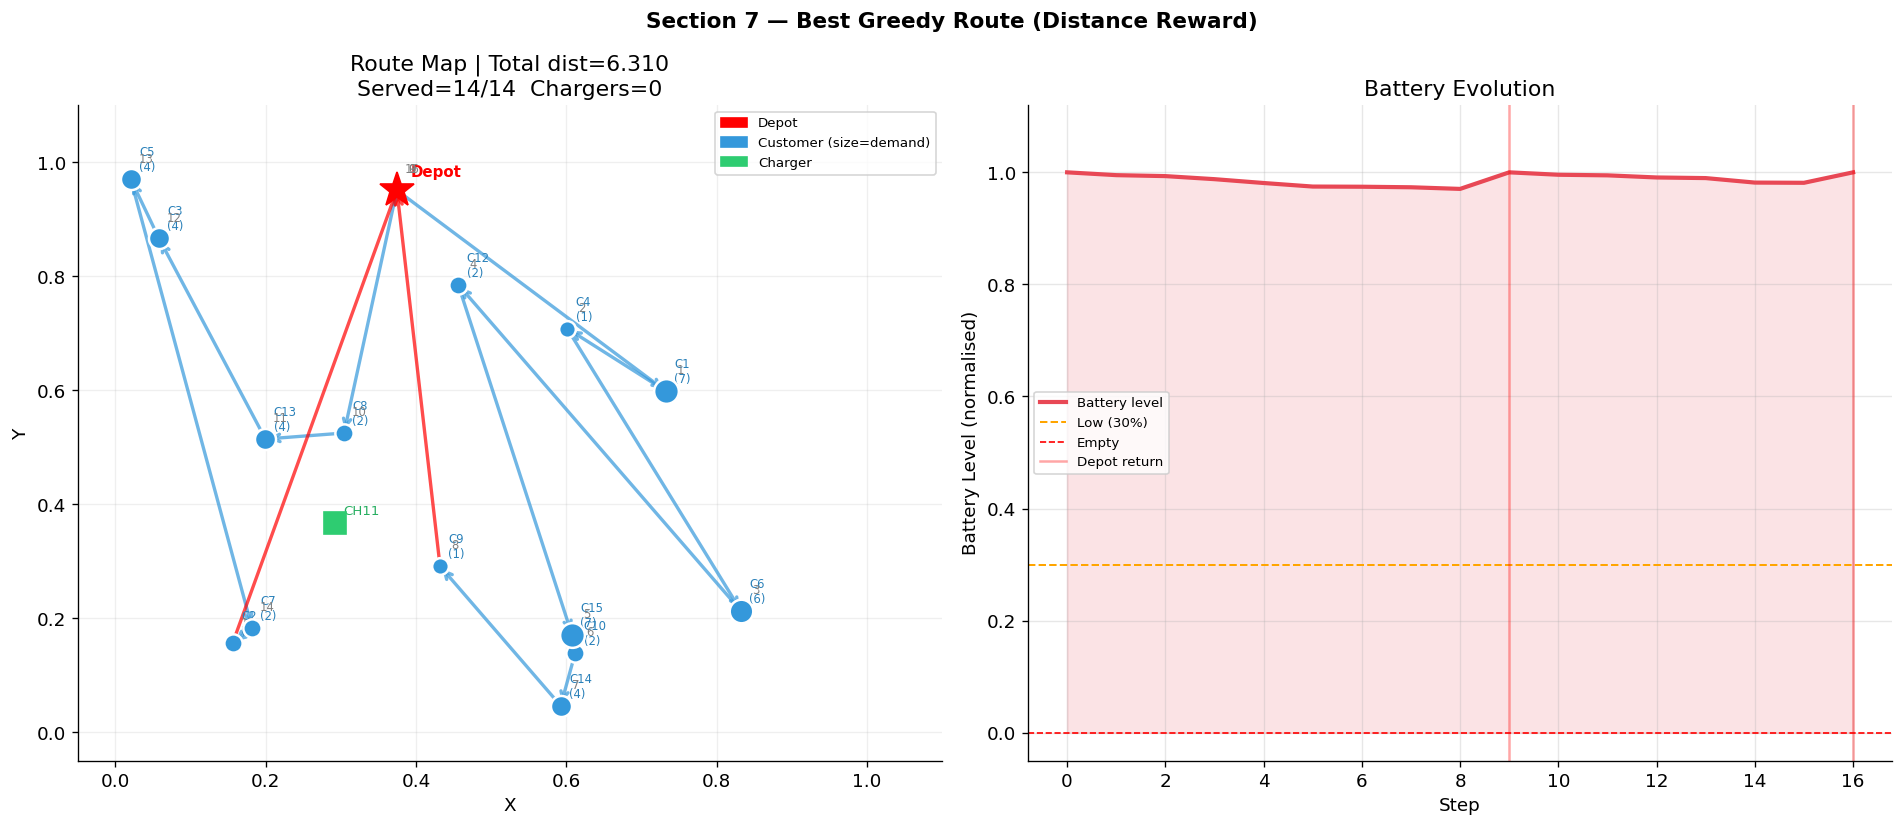

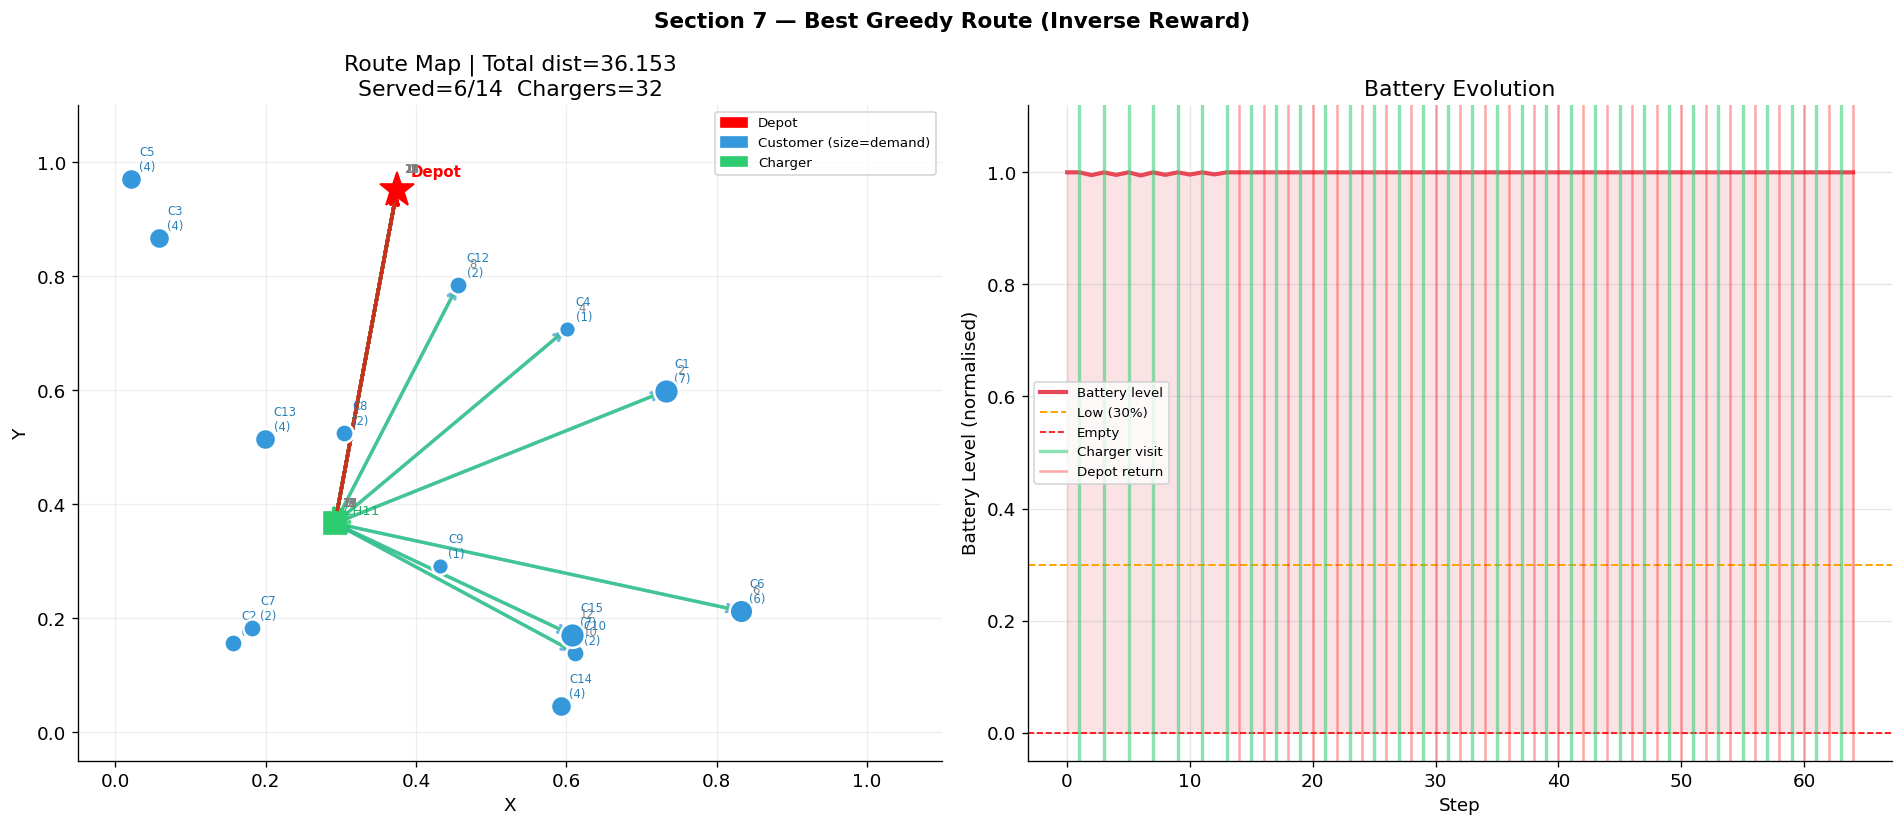

In [9]:
def plot_route_full(env, inst, route, traces, title='Route'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    coords = inst['coords']
    ntypes = inst['node_types']

    # ── Route map ─────────────────────────────────────────────────────────────
    ax = axes[0]
    for i in range(len(route) - 1):
        n1, n2 = route[i], route[i + 1]
        col_e = '#2ECC71' if ntypes[n2] == 2 else ('red' if n2 == 0 else '#3498DB')
        ax.annotate('', xy=coords[n2], xytext=coords[n1],
                    arrowprops=dict(arrowstyle='->', color=col_e, lw=2, alpha=0.7))

    for n in range(env.n):
        x, y = coords[n]
        if n == 0:
            ax.plot(x, y, '*', color='red', ms=22, zorder=6)
            ax.annotate('Depot', (x, y), textcoords='offset points',
                        xytext=(8, 8), fontsize=9, color='red', fontweight='bold')
        elif ntypes[n] == 1:
            sz = 80 + inst['demands'][n] * 20
            ax.scatter(x, y, s=sz, color='#3498DB', zorder=5,
                       edgecolors='white', lw=1.5)
            ax.annotate(f'C{n}\n({inst["demands"][n]:.0f})', (x, y),
                        textcoords='offset points', xytext=(5, 5),
                        fontsize=7, color='#2980B9')
        else:
            ax.plot(x, y, 's', color='#2ECC71', ms=13, zorder=5)
            ax.annotate(f'CH{n}', (x, y), textcoords='offset points',
                        xytext=(5, 5), fontsize=8, color='#27AE60')

    for i, n in enumerate(route[:25]):
        ax.text(coords[n, 0] + 0.02, coords[n, 1] + 0.03,
                str(i), fontsize=7, color='gray', ha='center')

    customers = np.where(ntypes == 1)[0]
    n_served  = sum(1 for n in route if ntypes[n] == 1)
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Route Map | Total dist={env.total_d:.3f}\n'
                 f'Served={n_served}/{len(customers)}  Chargers={env.charger_visits}')
    ax.legend(handles=[
        mpatches.Patch(color='red',     label='Depot'),
        mpatches.Patch(color='#3498DB', label='Customer (size=demand)'),
        mpatches.Patch(color='#2ECC71', label='Charger'),
    ], fontsize=8)
    ax.grid(alpha=0.2)

    # ── Battery evolution ──────────────────────────────────────────────────────
    ax2 = axes[1]
    batt      = np.array(env.battery_log)
    batt_norm = batt / inst['battery_cap']
    steps     = range(len(batt))
    ax2.fill_between(steps, 0, batt_norm, alpha=0.15, color='#E84855')
    ax2.plot(steps, batt_norm, color='#E84855', lw=2.5, label='Battery level')
    ax2.axhline(0.3, color='orange', ls='--', lw=1.2, label='Low (30%)')
    ax2.axhline(0.0, color='red',    ls='--', lw=1.0, label='Empty')

    seen_chg = seen_dep = False
    for i, n in enumerate(route):
        if i < len(batt):
            if ntypes[n] == 2:
                lbl = 'Charger visit' if not seen_chg else ''
                ax2.axvline(i, color='#2ECC71', alpha=0.55, lw=2, label=lbl)
                seen_chg = True
            if n == 0 and i > 0:
                lbl = 'Depot return' if not seen_dep else ''
                ax2.axvline(i, color='red', alpha=0.35, lw=1.5, label=lbl)
                seen_dep = True

    ax2.set_xlabel('Step')
    ax2.set_ylabel('Battery Level (normalised)')
    ax2.set_title('Battery Evolution')
    ax2.set_ylim(-0.05, 1.12)

    handles, labels = ax2.get_legend_handles_labels()
    seen_l = set(); uh, ul = [], []
    for h, l in zip(handles, labels):
        if l not in seen_l and l:
            seen_l.add(l); uh.append(h); ul.append(l)
    ax2.legend(uh, ul, fontsize=8)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    return fig


for mode in ['distance', 'inverse']:
    tr_data = TRACES[mode]
    fig = plot_route_full(
        tr_data['env'], tr_data['inst'], tr_data['route'], tr_data['traces'],
        title=f'Section 7 — Best Greedy Route ({mode.title()} Reward)'
    )
    plt.savefig(OUT / f'fig_route_{mode}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8 — XAI: Explanation Tracer
**Faithful XAI — reads directly from model internals:**
- Decoder cross-attention weights per step
- Encoder self-attention (per-node relational weights)
- Top-3 candidate nodes with probabilities
- Action confidence and entropy per step
- Attention-to-chosen-action vs max-attention alignment

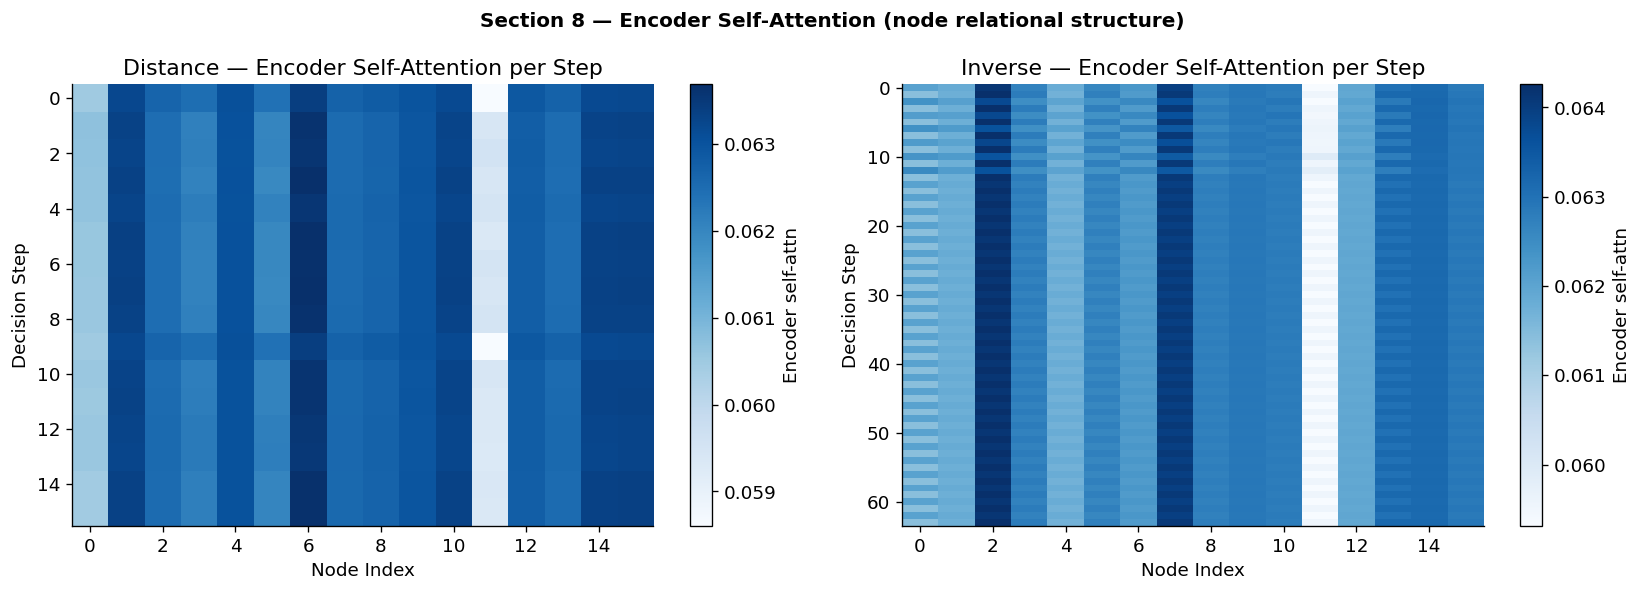

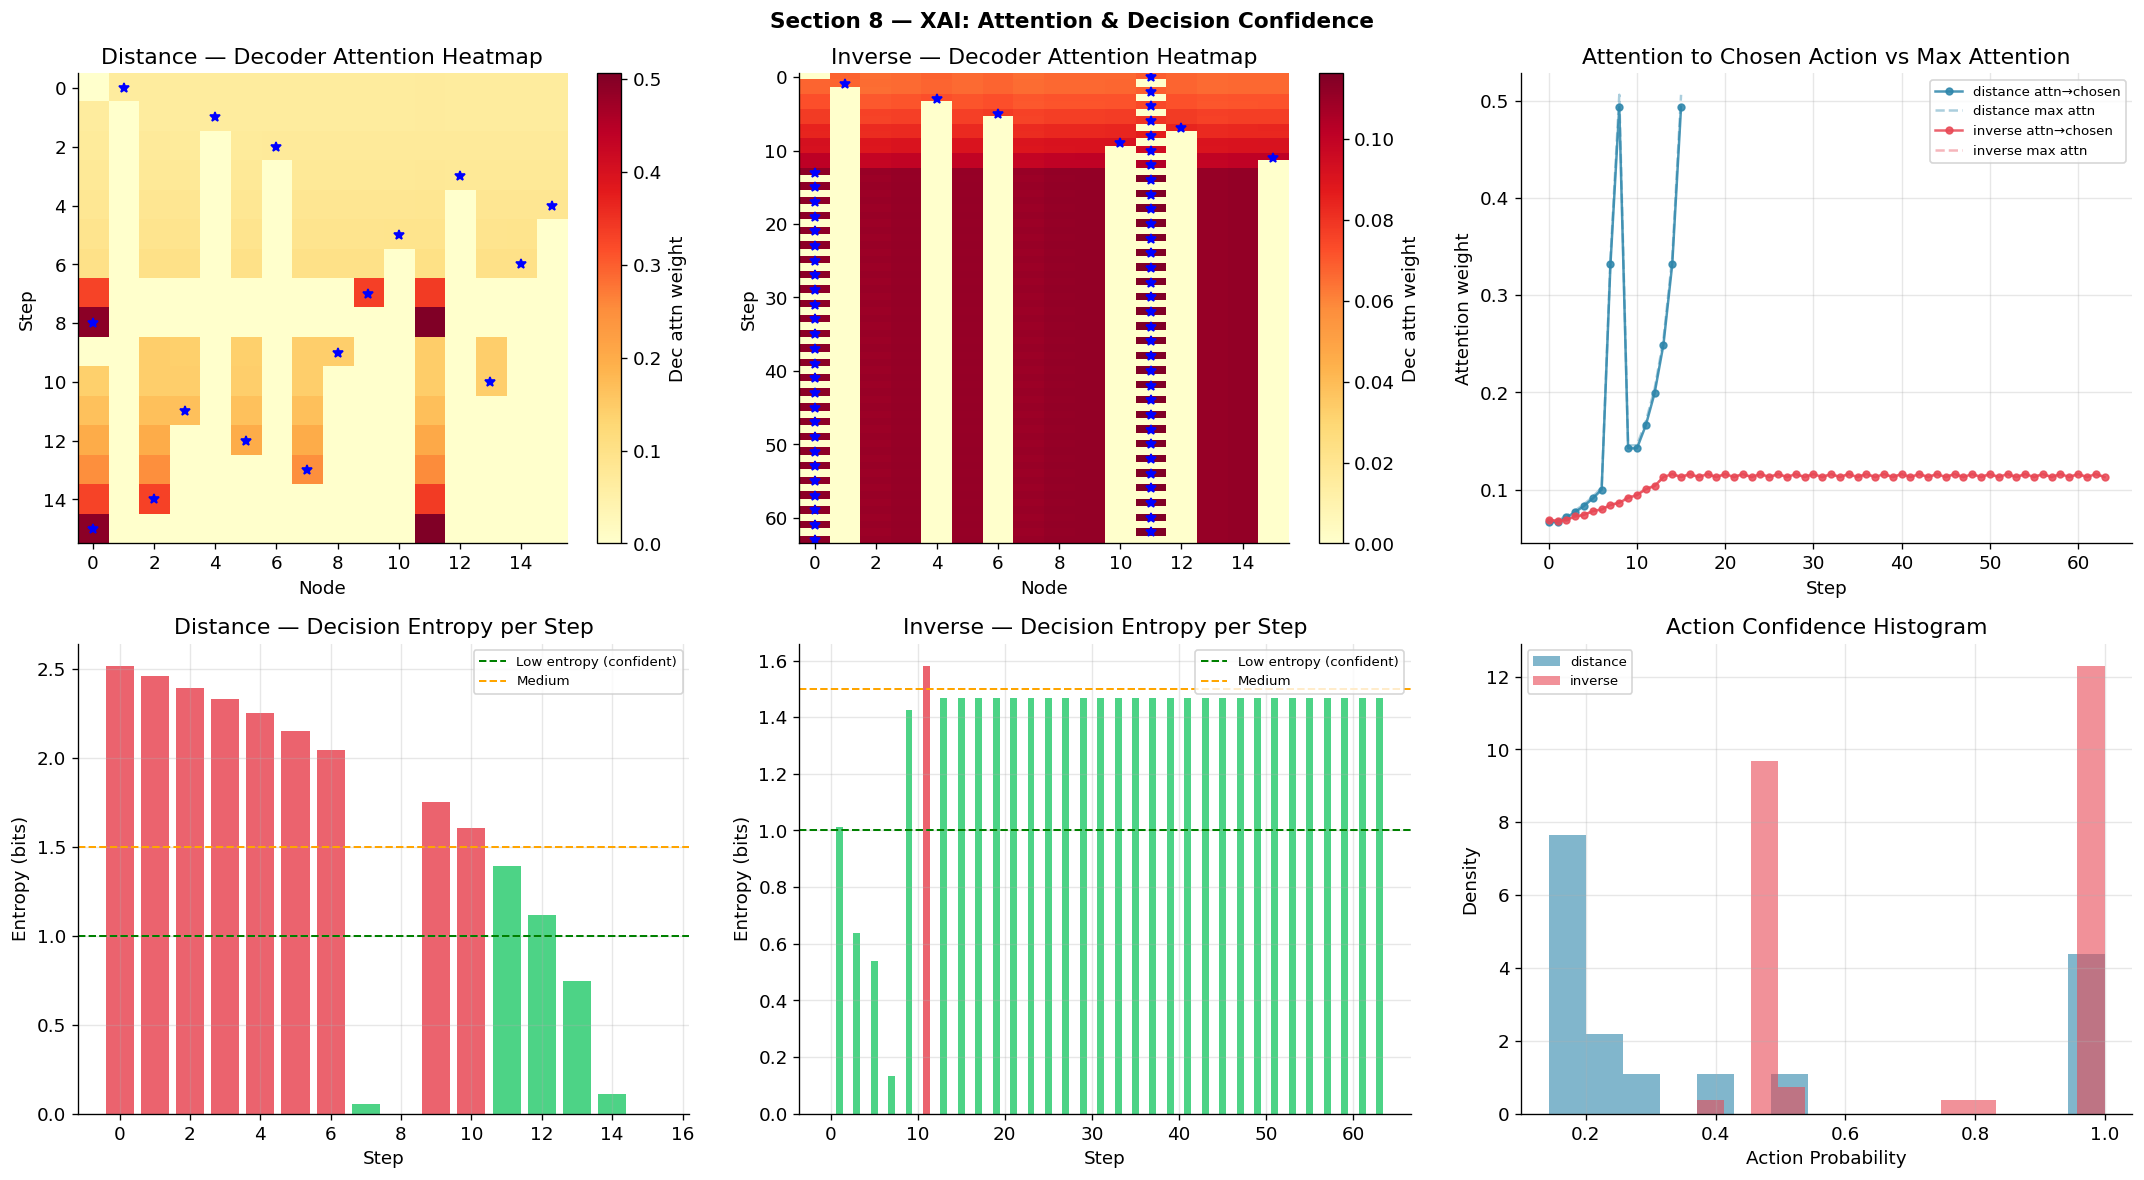

In [10]:
def plot_xai_analysis(traces_dist, traces_inv, n_nodes):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Section 8 — XAI: Attention & Decision Confidence',
                 fontsize=13, fontweight='bold')

    for ci, (mode, traces) in enumerate([('distance', traces_dist),
                                          ('inverse',  traces_inv)]):
        am = np.array([t['dec_attn'] for t in traces])

        # Heatmap
        ax = axes[0, ci]
        if am.shape[0] > 0 and am.max()-am.min() > 1e-5:
            im = ax.imshow(am, aspect='auto', cmap='YlOrRd')
            plt.colorbar(im, ax=ax, label='Dec attn weight')
            for i, t in enumerate(traces):
                if i < am.shape[0]: ax.plot(t['to_node'], i, 'b*', ms=6)
        ax.set_xlabel('Node'); ax.set_ylabel('Step')
        ax.set_title(f'{mode.title()} — Decoder Attention Heatmap')

        # Entropy per step
        ax2 = axes[1, ci]
        ep_ents = [float(Categorical(
            torch.softmax(torch.FloatTensor(t['raw_logits']),-1)).entropy().item())
            for t in traces]
        c_ent = ['#E84855' if e>1.5 else '#2ECC71' for e in ep_ents]
        ax2.bar(range(len(ep_ents)), ep_ents, color=c_ent, alpha=0.85)
        ax2.axhline(1.0, color='green',  ls='--', lw=1.2, label='Low entropy (confident)')
        ax2.axhline(1.5, color='orange', ls='--', lw=1.2, label='Medium')
        ax2.set_xlabel('Step'); ax2.set_ylabel('Entropy (bits)')
        ax2.set_title(f'{mode.title()} — Decision Entropy per Step')
        ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # Attention-to-chosen vs max attention
    ax3 = axes[0, 2]
    for mode, col in COLS.items():
        traces = TRACES[mode]['traces']
        am = np.array([t['dec_attn'] for t in traces])
        attn_chosen = [am[i, t['to_node']] if i < len(am) else 0 for i, t in enumerate(traces)]
        attn_max    = [am[i].max() if i < len(am) else 0 for i in range(len(traces))]
        ax3.plot(attn_chosen, '-o', color=col, ms=4, alpha=0.85, label=f'{mode} attn→chosen')
        ax3.plot(attn_max,    '--', color=col, alpha=0.4,          label=f'{mode} max attn')
    ax3.set_xlabel('Step'); ax3.set_ylabel('Attention weight')
    ax3.set_title('Attention to Chosen Action vs Max Attention')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    # Confidence histogram
    ax4 = axes[1, 2]
    for mode, col in COLS.items():
        probs_all = [t['action_prob'] for t in TRACES[mode]['traces']]
        ax4.hist(probs_all, bins=15, alpha=0.6, color=col, label=mode, density=True)
    ax4.set_xlabel('Action Probability'); ax4.set_ylabel('Density')
    ax4.set_title('Action Confidence Histogram')
    ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT/'fig_xai_attention.png', dpi=150, bbox_inches='tight')
    plt.show()

# Encoder self-attention heatmap (shows node-to-node relational structure)
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Section 8 — Encoder Self-Attention (node relational structure)',
              fontsize=12, fontweight='bold')
for ci, mode in enumerate(['distance','inverse']):
    enc_am = np.array([t['enc_attn'] for t in TRACES[mode]['traces']])
    ax = axes2[ci]
    if enc_am.max()-enc_am.min() > 1e-5:
        im = ax.imshow(enc_am, aspect='auto', cmap='Blues')
        plt.colorbar(im, ax=ax, label='Encoder self-attn')
    ax.set_title(f'{mode.title()} — Encoder Self-Attention per Step')
    ax.set_xlabel('Node Index'); ax.set_ylabel('Decision Step')
plt.tight_layout()
plt.savefig(OUT/'fig_xai_encoder_attn.png', dpi=150, bbox_inches='tight')
plt.show()

plot_xai_analysis(TRACES['distance']['traces'], TRACES['inverse']['traces'],
                  TRACES['distance']['env'].n)

## 9 — XAI: Counterfactual Analyzer
**Proves the model's internal reasoning — not just masking artefacts.**

For each perturbation we measure TWO things:
1. **Action change rate** (masked): does the chosen action change?
2. **Logit shift** (unmasked): does the model's *internal scoring* shift?

The logit shift is measured on raw pre-mask logits, so we capture  
genuine learned sensitivity to battery/cargo — independent of what the mask blocks.

distance:
               action_change_rate  logit_shift
perturbation                                  
battery_+20%                  0.0       0.0000
battery_-15%                  0.0       0.0001
battery_-30%                  0.0       0.0001
cargo_+30%                    0.0       0.0001
cargo_-50%                    0.0       0.0001
mask_disabled                 0.0       0.0000
inverse:
               action_change_rate  logit_shift
perturbation                                  
battery_+20%                  0.0       0.0000
battery_-15%                  0.0       0.0001
battery_-30%                  0.0       0.0003
cargo_+30%                    0.0       0.0001
cargo_-50%                    0.0       0.0003
mask_disabled                 0.0       0.0000


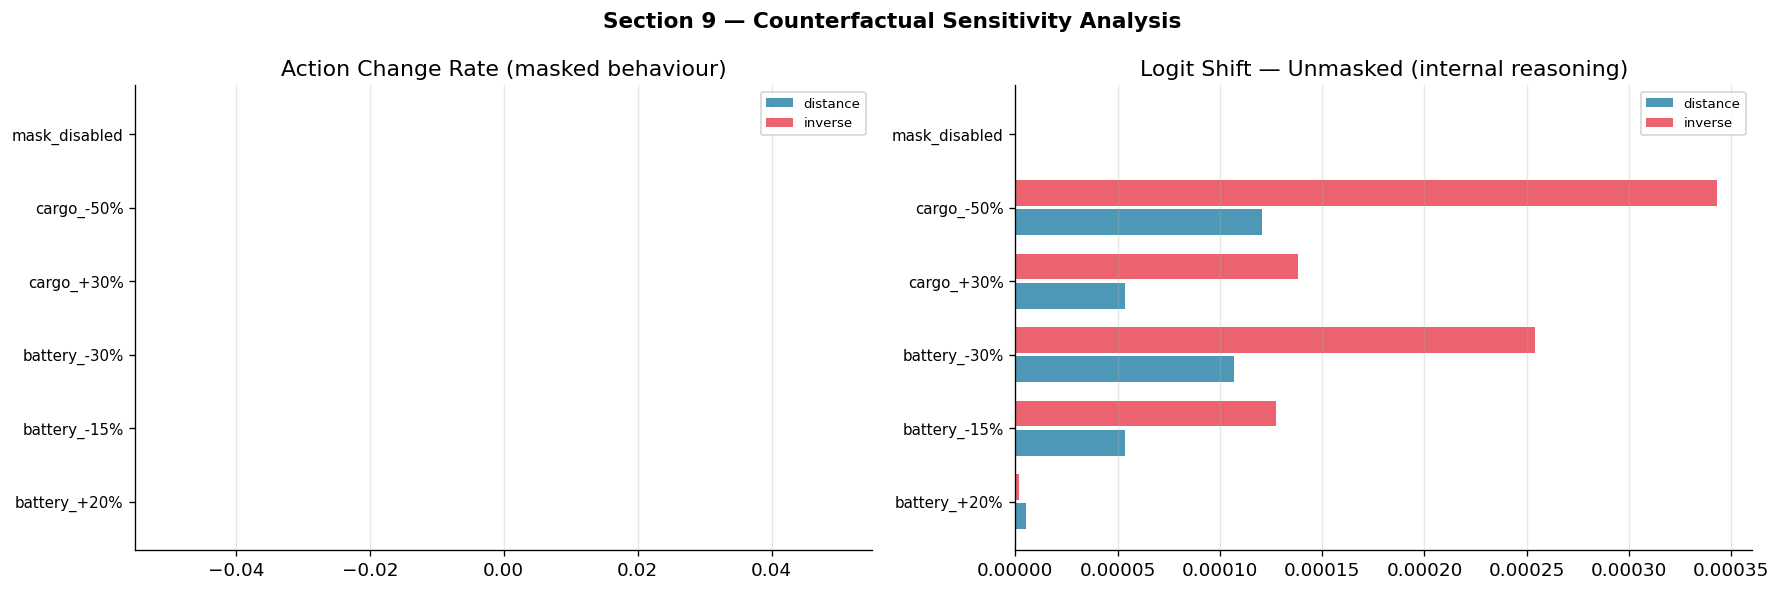

In [11]:
PERTURBATIONS = [
    dict(name='battery_+20%',  bat=1.20, cargo=None),
    dict(name='battery_-15%',  bat=0.85, cargo=None),
    dict(name='battery_-30%',  bat=0.70, cargo=None),
    dict(name='cargo_+30%',    bat=None, cargo=1.30),
    dict(name='cargo_-50%',    bat=None, cargo=0.50),
    dict(name='mask_disabled', bat=None, cargo=None),
]

def get_raw_logits(agent, obs):
    """Unmasked logits — bypasses feasibility mask."""
    feats   = obs['node_features'].unsqueeze(0).to(DEVICE)
    bat_t   = torch.FloatTensor([[obs['battery_norm']]]).to(DEVICE)
    car_t   = torch.FloatTensor([[obs['cargo_norm']]]).to(DEVICE)
    cur_t   = torch.LongTensor([obs['current_node']]).to(DEVICE)
    inv_all = torch.zeros(1, obs['node_features'].shape[0], dtype=torch.bool).to(DEVICE)
    node_emb, graph_emb = agent.encoder(feats)
    scores = agent.decoder(node_emb, graph_emb, bat_t, car_t, cur_t, inv_all)
    return scores.squeeze(0).cpu().detach().numpy()

def cf_analysis(agent, inst, n_trials=25):
    rows = []
    for trial in range(n_trials):
        inst_t = dict(inst, reward_mode=inst.get('reward_mode', 'distance'))
        with torch.no_grad():
            _, _, _, _, _, traces_base, _ = run_episode(
                agent, inst_t, greedy=True, collect_traces=True)
        if not traces_base:
            continue

        for pert in PERTURBATIONS:
            pname    = pert['name']
            bm       = pert['bat']
            cm       = pert['cargo']

            with torch.no_grad():
                _, _, _, _, _, traces_pert, _ = run_episode(
                    agent, inst_t, greedy=True, collect_traces=True,
                    bat_perturb=bm, cargo_perturb=cm)
            if not traces_pert:
                continue

            n      = min(len(traces_base), len(traces_pert))
            act_ch = [int(traces_base[i]['to_node'] != traces_pert[i]['to_node'])
                      for i in range(n)]

            # Logit shift on unmasked raw policy
            env_t = EVRPEnv(inst_t, reward_mode=inst_t.get('reward_mode', 'distance'))
            obs   = env_t.reset()
            done  = False
            step  = 0
            lshifts = []

            while not done and step < min(n, 8):
                obs_p = dict(obs)
                if bm is not None:
                    obs_p['battery_norm'] = float(np.clip(obs['battery_norm'] * bm, 0, 1))
                if cm is not None:
                    obs_p['cargo_norm']   = float(np.clip(obs['cargo_norm']   * cm, 0, 1))

                with torch.no_grad():
                    bl = get_raw_logits(agent, obs)
                    pl = get_raw_logits(agent, obs_p)
                lshifts.append(float(np.abs(bl - pl).mean()))

                vm    = env_t._valid_mask()
                feats = obs['node_features'].unsqueeze(0).to(DEVICE)
                bat_t = torch.FloatTensor([[obs['battery_norm']]]).to(DEVICE)
                car_t = torch.FloatTensor([[obs['cargo_norm']]]).to(DEVICE)
                cur_t = torch.LongTensor([obs['current_node']]).to(DEVICE)
                inv_t = torch.BoolTensor(~vm).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    ne, ge = agent.encoder(feats)
                    sc     = agent.decoder(ne, ge, bat_t, car_t, cur_t, inv_t)
                    action = sc.squeeze(0).argmax().item()

                obs, _, done, _ = env_t.step(action)
                step += 1

            rows.append(dict(
                trial=trial,
                perturbation=pname,
                action_change_rate=float(np.mean(act_ch)),
                logit_shift=float(np.mean(lshifts)) if lshifts else 0.0,
            ))

    return pd.DataFrame(rows)


# ── Run counterfactual analysis ───────────────────────────────────────────────
CF = {}
inst_cf_dist = dict(generate_instance(N_CUSTOMERS, seed=42), reward_mode='distance')
inst_cf_inv  = dict(generate_instance(N_CUSTOMERS, seed=42), reward_mode='inverse')

for mode in ['distance', 'inverse']:
    inst_cf   = inst_cf_dist if mode == 'distance' else inst_cf_inv
    CF[mode]  = cf_analysis(RESULTS[mode][42]['agent'], inst_cf, n_trials=20)
    print(f'{mode}:')
    print(CF[mode].groupby('perturbation')[['action_change_rate', 'logit_shift']].mean().round(4))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section 9 — Counterfactual Sensitivity Analysis',
             fontsize=13, fontweight='bold')

for ax, metric, title in zip(
        axes,
        ['action_change_rate', 'logit_shift'],
        ['Action Change Rate (masked behaviour)',
         'Logit Shift — Unmasked (internal reasoning)']):
    perts = list(CF['distance'].groupby('perturbation')[metric].mean().index)
    xp    = np.arange(len(perts))
    for off, mode, col in [(-0.2, 'distance', '#2E86AB'), (0.2, 'inverse', '#E84855')]:
        g = CF[mode].groupby('perturbation')[metric].mean()
        ax.barh(xp + off, [g.get(p, 0) for p in perts], 0.35,
                color=col, alpha=0.85, label=mode)
    ax.set_yticks(xp)
    ax.set_yticklabels(perts, fontsize=9)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUT / 'fig_xai_counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — XAI: Feature Importance (Logit Ablation)
SHAP-style: zero out each input feature, measure mean absolute logit shift.  
Uses **unmasked raw logits** so results are not confounded by the feasibility mask.

distance: top features = ['is_charger', 'cargo_cap_norm', 'x_coord']
inverse: top features = ['x_coord', 'y_coord', 'is_charger']


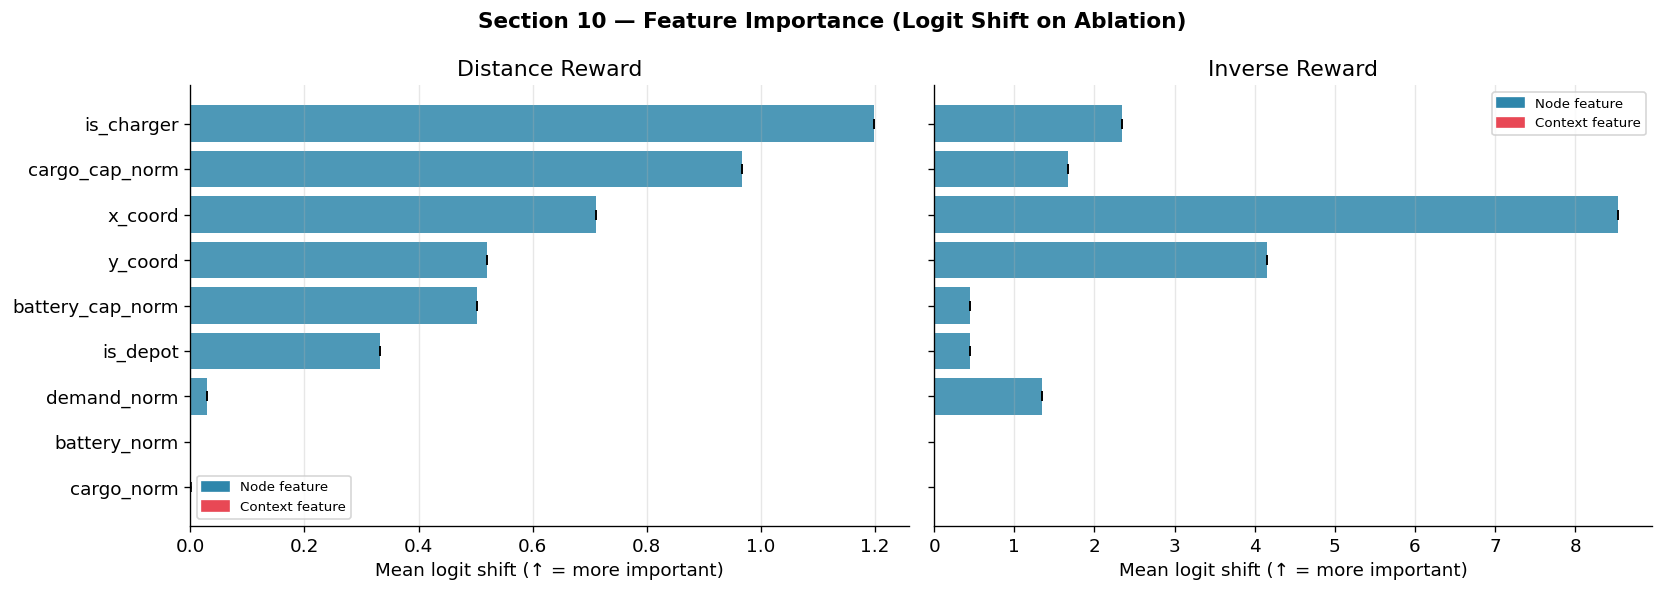

In [12]:
NODE_FEATS = ['x_coord','y_coord','demand_norm','is_charger','is_depot',
               'cargo_cap_norm','battery_cap_norm']
CTX_FEATS  = ['battery_norm','cargo_norm']

def feature_importance(agent, inst, n_trials=25):
    imp = {f: [] for f in NODE_FEATS + CTX_FEATS}
    for trial in range(n_trials):
        env = EVRPEnv(inst, reward_mode=inst.get('reward_mode','distance'))
        obs = env.reset(); done = False; step = 0
        while not done and step < 8:
            nf  = obs['node_features'].to(DEVICE)
            bat = obs['battery_norm']; car = obs['cargo_norm']
            base = get_raw_logits(agent, obs)

            for fi, fn in enumerate(NODE_FEATS):
                nf_ab   = nf.clone(); nf_ab[:, fi] = 0.0
                obs_ab  = dict(obs, node_features=nf_ab.cpu())
                with torch.no_grad(): ab = get_raw_logits(agent, obs_ab)
                imp[fn].append(float(np.abs(base-ab).mean()))

            for cn, cv in [('battery_norm', bat*0), ('cargo_norm', car*0)]:
                obs_ab = dict(obs); obs_ab[cn] = 0.0
                with torch.no_grad(): ab = get_raw_logits(agent, obs_ab)
                imp[cn].append(float(np.abs(base-ab).mean()))

            vm = env._valid_mask(); v = np.where(vm)[0]
            feats  = obs['node_features'].unsqueeze(0).to(DEVICE)
            bat_t  = torch.FloatTensor([[bat]]).to(DEVICE)
            car_t  = torch.FloatTensor([[car]]).to(DEVICE)
            cur_t  = torch.LongTensor([obs['current_node']]).to(DEVICE)
            inv_t  = torch.BoolTensor(~vm).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                ne, ge = agent.encoder(feats)
                sc = agent.decoder(ne, ge, bat_t, car_t, cur_t, inv_t)
            obs, _, done, _ = env.step(sc.squeeze(0).argmax().item()); step += 1
    return {k: (float(np.mean(v)), float(np.std(v))) for k, v in imp.items() if v}

FI = {}
for mode in ['distance','inverse']:
    inst_fi = dict(generate_instance(N_CUSTOMERS, seed=42), reward_mode=mode)
    FI[mode] = feature_importance(RESULTS[mode][42]['agent'], inst_fi, n_trials=20)
    top = sorted(FI[mode].items(), key=lambda x: -x[1][0])[:3]
    print(f'{mode}: top features = {[t[0] for t in top]}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Section 10 — Feature Importance (Logit Shift on Ablation)',
             fontsize=13, fontweight='bold')
for ax, mode in zip(axes, ['distance','inverse']):
    names_fi = sorted(FI[mode], key=lambda n: FI[mode][n][0])
    means_fi = [FI[mode][n][0] for n in names_fi]
    stds_fi  = [FI[mode][n][1] for n in names_fi]
    c_fi = ['#2E86AB' if n in NODE_FEATS else '#E84855' for n in names_fi]
    ax.barh(names_fi, means_fi, xerr=stds_fi, color=c_fi, alpha=0.85, capsize=3)
    ax.set_xlabel('Mean logit shift (↑ = more important)')
    ax.set_title(f'{mode.title()} Reward'); ax.grid(alpha=0.3, axis='x')
    ax.legend(handles=[mpatches.Patch(color='#2E86AB',label='Node feature'),
                        mpatches.Patch(color='#E84855',label='Context feature')], fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'fig_xai_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 — LLM Explanation Layer
**Generates faithful, grounded decision reports.**

Each report is built from:
- Actual model state (battery %, cargo %, distance)
- Real attention weights from the encoder/decoder
- Counterfactual sensitivity of this specific step
- Top-3 candidate nodes with actual probabilities

Output format:
```
STEP_SUMMARY: Step N: Node X (type) | Reason: ... | Confidence: P
ONE_LINE:     ...
OPERATOR:     ...
TECHNICAL:    ...
FRAGILITY:    LOW/MEDIUM/HIGH — reason
```

In [17]:
import time

# ── Fix 1: switch to lightweight model (uses ~10x fewer tokens) ──────────────
GROQ_MODEL = 'llama-3.1-8b-instant'   # fast, cheap, same API
print(f'Model: {GROQ_MODEL}')

# ── Fix 2: call_groq with retry and sleep ────────────────────────────────────
def call_groq(prompt, max_retries=3):
    if not GROQ_API_KEY:
        return None, 'missing_api_key'

    for attempt in range(max_retries):
        try:
            r = requests.post(
                'https://api.groq.com/openai/v1/chat/completions',
                json={
                    'model':       GROQ_MODEL,
                    'max_tokens':  300,
                    'temperature': 0.2,
                    'messages':    [{'role': 'user', 'content': prompt}],
                },
                headers={
                    'Authorization': f'Bearer {GROQ_API_KEY}',
                    'Content-Type':  'application/json',
                },
                timeout=30,
            )

            if r.status_code == 429:
                # Extract wait time from error message
                import re
                wait_match = re.search(r'try again in (\d+)m([\d.]+)s', r.text)
                if wait_match:
                    wait_secs = int(wait_match.group(1)) * 60 + float(wait_match.group(2))
                else:
                    wait_secs = 30
                wait_secs = min(wait_secs, 60)   # cap at 60 seconds
                print(f'  Rate limited. Waiting {wait_secs:.0f}s (attempt {attempt+1}/{max_retries})...')
                time.sleep(wait_secs + 2)
                continue

            if not r.ok:
                print(f'  Groq HTTP {r.status_code}: {r.text[:200]}')
                return None, f'http_{r.status_code}'

            text = r.json()['choices'][0]['message']['content']
            return text, 'groq'

        except Exception as ex:
            print(f'  Groq exception: {ex}')
            if attempt < max_retries - 1:
                time.sleep(10)
            else:
                return None, str(ex)

    return None, 'max_retries_exceeded'


# ── Fix 3: shorter prompt to save tokens ─────────────────────────────────────
def build_prompt(trace, inst, cf_row, mode):
    atype    = NODE_TYPE_STR.get(trace.get('node_type', -1), '?')
    nlbl     = node_label(trace.get('to_node', -1), trace.get('node_type', -1))
    bat      = safe_float(trace.get('battery_norm', 0.0))
    cargo    = safe_float(trace.get('cargo_norm',   0.0))
    prob     = safe_float(trace.get('action_prob',  0.0))
    dist_act = safe_float(trace.get('dist_to_action', 0.0))
    cf_shift = safe_float(cf_row.get('logit_shift', 0.0)) if cf_row else 0.0

    finite  = finite_logits_only(trace.get('raw_logits', []))
    n_valid = len(finite)
    if n_valid > 1:
        p   = torch.softmax(torch.tensor(finite, dtype=torch.float32), -1)
        ent = float(Categorical(p).entropy().item())
    else:
        ent = 0.0

    max_ent = math.log2(max(n_valid, 2))
    rel_ent = ent / max_ent if max_ent > 0 else 0.0

    rmode = ('rewards short hops' if mode == 'inverse' else 'minimises total distance')

    # Keep prompt under 300 tokens
    lines = [
        f'EV routing step {trace.get("step")}. Mode={mode} ({rmode}).',
        f'Chosen: {nlbl} ({atype}). Battery={bat:.0%}. Cargo={cargo:.0%}.',
        f'Prob={prob:.2f}. Dist={dist_act:.3f}. Valid_actions={n_valid}.',
        f'Relative_entropy={rel_ent:.2f}. CF_shift={cf_shift:.5f}.',
        f'Top3={summarise_topk(trace, 3)}.',
        '',
        'Write exactly 5 lines:',
        'STEP_SUMMARY: Step N: Chosen: <label> (<type>) | Reason: <reason> | Confidence: <prob>',
        'ONE_LINE: <max 12 words explaining the key reason>',
        'OPERATOR: <2 plain sentences for a logistics manager>',
        'TECHNICAL: <2 ML sentences with numbers from above>',
        'FRAGILITY: <LOW/MEDIUM/HIGH> — <one sentence why>',
    ]
    return '\n'.join(lines)


# ── Generate reports with sleep between calls ─────────────────────────────────
LLM_REPORTS = []

for mode in ['distance', 'inverse']:
    if mode not in TRACES:
        continue
    traces = TRACES[mode].get('traces', [])
    inst   = TRACES[mode].get('inst',   {})
    n_st   = len(traces)
    if n_st == 0:
        continue

    idxs  = sorted(set([0, n_st//5, n_st//3, n_st//2, 2*n_st//3, n_st-1]))
    cf_df = CF.get(mode, pd.DataFrame()) if 'CF' in globals() else pd.DataFrame()

    for idx in idxs:
        if idx >= n_st:
            continue
        trace = traces[idx]

        cf_row = None
        if not cf_df.empty:
            cf_sub = cf_df[cf_df['perturbation'] == 'battery_-30%']
            if not cf_sub.empty:
                cf_row = cf_sub.iloc[min(idx, len(cf_sub)-1)].to_dict()

        prompt = build_prompt(trace, inst, cf_row, mode)

        if LLM_ENABLED:
            text, src = call_groq(prompt)
            if text is None:
                print(f'  LLM failed → rule-based')
                text, src = rule_based_report(trace, inst, cf_row, mode), 'rule-based'
            else:
                # Small sleep between successful calls to stay under rate limit
                time.sleep(2)
        else:
            text, src = rule_based_report(trace, inst, cf_row, mode), 'rule-based'

        rep = dict(mode=mode, step=int(trace.get('step', idx)),
                   source=src, state=trace, report=text)
        LLM_REPORTS.append(rep)
        print(f'\n=== [{mode.upper()} | Step {trace.get("step", idx):02d} | {src}] ===')
        print(text)

with open(OUT / 'llm_reports_full.json', 'w', encoding='utf-8') as f:
    json.dump(LLM_REPORTS, f, indent=2, ensure_ascii=False, default=str)
print(f'\n{len(LLM_REPORTS)} reports saved ✓')

Model: llama-3.1-8b-instant

=== [DISTANCE | Step 00 | groq] ===
STEP_SUMMARY: Step 0: Chosen: C1 (customer) | Reason: Minimizing total distance | Confidence: 0.14
ONE_LINE: Chosen customer C1 to minimize total distance traveled.
OPERATOR: As a logistics manager, we've chosen customer C1 to minimize total distance traveled, which is a key factor in reducing fuel costs and increasing efficiency.
TECHNICAL: The chosen action is based on the mode set to distance, with a probability of 0.14 and a distance of 0.502. The relative entropy is 0.64 and the CF_shift is 0.00011.
FRAGILITY: LOW — The chosen action is relatively stable due to the high battery level and full cargo capacity.

=== [DISTANCE | Step 03 | groq] ===
STEP_SUMMARY: Step N: Chosen: C12 (customer) | Reason: Minimizes total distance | Confidence: 0.16
ONE_LINE: Chosen route minimizes total distance with high confidence.
OPERATOR: As the logistics manager, I've chosen route C12 to minimize total distance. This decision aims to 

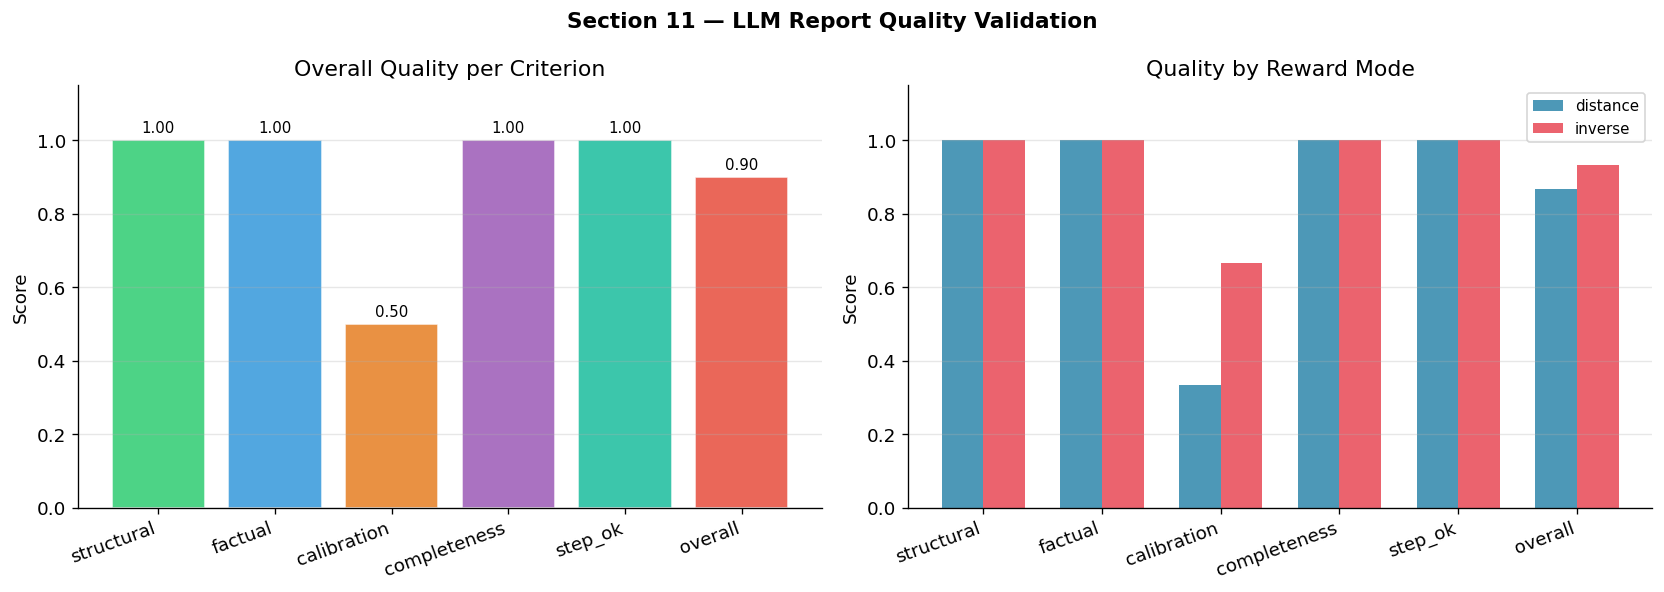

structural      1.0
factual         1.0
calibration     0.5
completeness    1.0
step_ok         1.0
overall         0.9


In [ ]:
# ── LLM Validation & Visualisation ───────────────────────────────────────────
def validate_report(rep):
    t = rep['report']; s = rep.get('state', {})
    bat   = s.get('battery_norm', 0.5)
    prob  = s.get('action_prob',  0.5)
    logits= s.get('raw_logits', [])
    ep    = float(Categorical(torch.softmax(torch.FloatTensor(logits),-1)).entropy().item()) if logits else 0

    structural   = sum(f in t for f in ['STEP_SUMMARY:','ONE_LINE:','OPERATOR:','TECHNICAL:','FRAGILITY:']) / 5.0
    bat_pct      = f"{bat*100:.0f}%"
    factual      = float(bat_pct in t or str(s.get('to_node','')) in t)
    expects_hi   = ep > 1.5 or bat < 0.3 or prob < 0.5
    calibration  = float(expects_hi == ('HIGH' in t))
    try:
        op_text      = t.split('OPERATOR:')[1].split('TECHNICAL:')[0].strip()
        completeness = float(len(op_text) > 40)
    except (IndexError, AttributeError):
        completeness = 0.0
    step_ok = float('STEP_SUMMARY:' in t and 'Confidence:' in t)
    overall = float(np.mean([structural, factual, calibration, completeness, step_ok]))
    return dict(mode=rep.get('mode','?'), structural=structural, factual=factual,
                calibration=calibration, completeness=completeness,
                step_ok=step_ok, overall=overall)

VAL_METRICS = ['structural','factual','calibration','completeness','step_ok','overall']
val_df = pd.DataFrame([validate_report(r) for r in LLM_REPORTS])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 11 — LLM Report Quality Validation',
             fontsize=13, fontweight='bold')
means_v = val_df[VAL_METRICS].mean()
colours_v = ['#2ECC71','#3498DB','#E67E22','#9B59B6','#1ABC9C','#E74C3C']
bars = axes[0].bar(VAL_METRICS, means_v, color=colours_v, alpha=0.85, edgecolor='white')
axes[0].set_ylim(0,1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Overall Quality per Criterion')
axes[0].set_xticklabels(VAL_METRICS, rotation=20, ha='right')
axes[0].grid(alpha=0.3, axis='y')
for b, v in zip(bars, means_v):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=9)

if val_df['mode'].nunique() > 1:
    mm = val_df.groupby('mode')[VAL_METRICS].mean()
    xv = np.arange(len(VAL_METRICS)); w = 0.35
    for oi, (mname, col) in enumerate(zip(mm.index, ['#2E86AB','#E84855'])):
        axes[1].bar(xv+(oi-0.5)*w, mm.loc[mname,VAL_METRICS], w,
                    label=mname, color=col, alpha=0.85)
    axes[1].set_xticks(xv); axes[1].set_xticklabels(VAL_METRICS, rotation=20, ha='right')
    axes[1].set_ylim(0,1.15); axes[1].set_ylabel('Score')
    axes[1].set_title('Quality by Reward Mode'); axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT/'fig_llm_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(val_df[VAL_METRICS].mean().round(3).to_string())

## 12 — Evaluation vs Baselines
Compares A2C+GAT against Random and Greedy-NN on 60 held-out instances.

Method                       Dist     Std   Feasible   Cust  Chargers  BattViol
------------------------------------------------------------------------------
A2C+GAT (Dist)              6.229   1.209    100.0%   12.8      0.00      0.00
A2C+GAT (Inve)             28.709  14.900     11.7%    3.6     49.88      0.00
Greedy-NN                  13.540   7.287     26.7%    8.0     32.02      0.00
Random                     12.483   2.829    100.0%   12.8      7.62      0.00


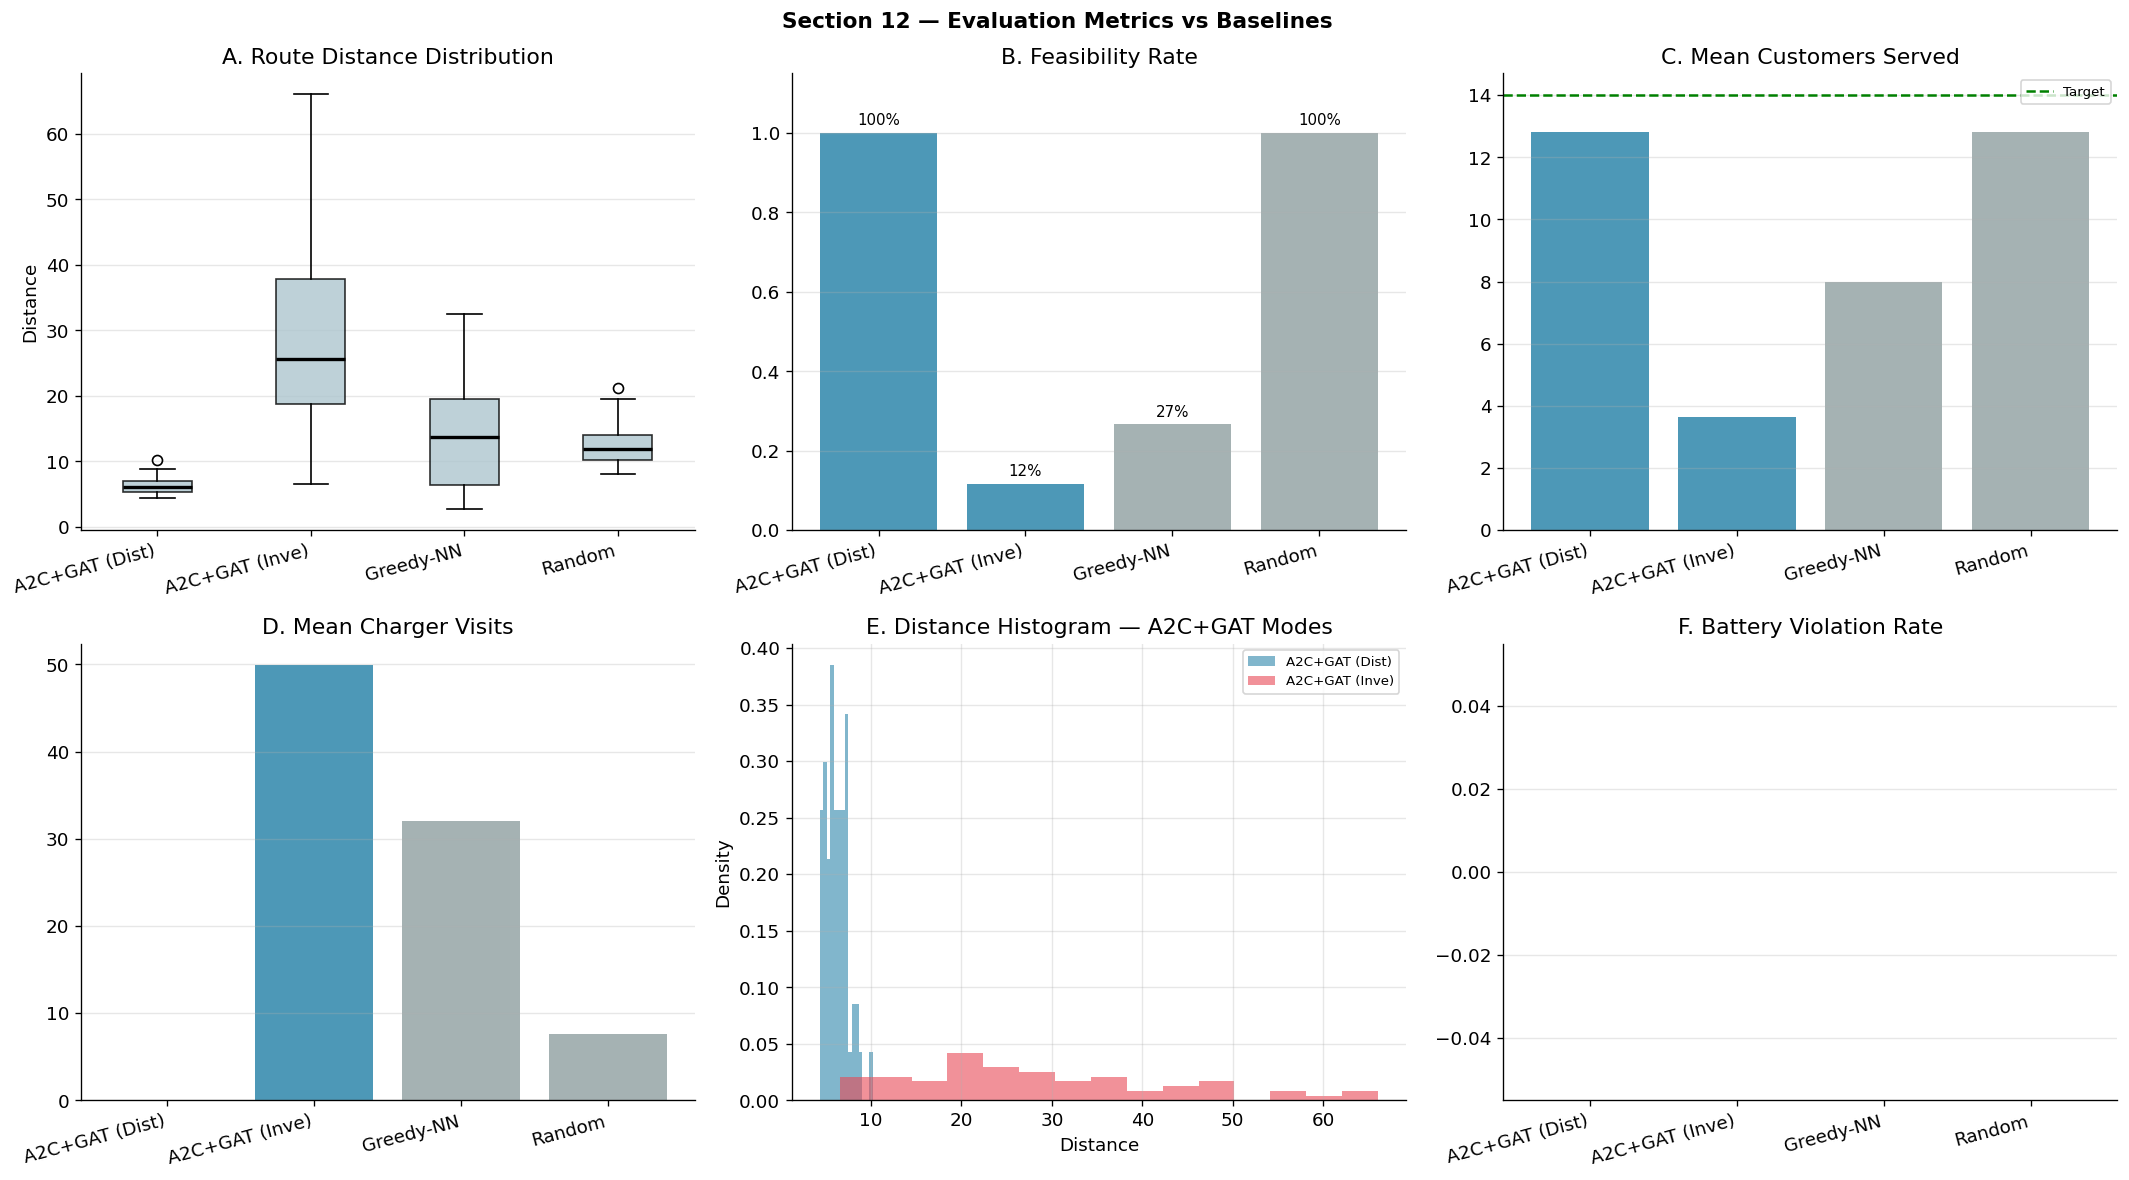

In [ ]:
def full_eval(agent, mode, n=60):
    ds, fs, cs, chg, bv = [], [], [], [], []
    for t in range(n):
        inst = dict(generate_instance(N_CUSTOMERS, seed=t+500), reward_mode=mode)
        with torch.no_grad():
            _, _, d, info, _, _, env = run_episode(agent, inst, greedy=True)
        ds.append(d); fs.append(int(info['all_served']))
        cs.append(info['n_customers_served']); chg.append(info['charger_visits'])
        bv.append(info['batt_violations'])
    return dict(dist=np.array(ds), feas=np.array(fs), cust=np.array(cs),
                chargers=np.array(chg), batt_viol=np.array(bv))

def greedy_nn_eval(mode, n=60):
    ds, fs, cs, chg = [], [], [], []
    for t in range(n):
        inst = dict(generate_instance(N_CUSTOMERS, seed=t+500), reward_mode=mode)
        env  = EVRPEnv(inst, reward_mode=mode); obs = env.reset(); done = False
        while not done:
            vm = env._valid_mask(); v = np.where(vm)[0]
            _, _, done, info = env.step(v[env.D[env.cur, v].argmin()])
        ds.append(env.total_d); fs.append(int(info['all_served']))
        cs.append(info['n_customers_served']); chg.append(info['charger_visits'])
    return dict(dist=np.array(ds), feas=np.array(fs), cust=np.array(cs), chargers=np.array(chg))

def random_eval(mode, n=60):
    ds, fs, cs, chg = [], [], [], []
    for t in range(n):
        inst = dict(generate_instance(N_CUSTOMERS, seed=t+500), reward_mode=mode)
        env  = EVRPEnv(inst, reward_mode=mode); obs = env.reset(); done = False
        while not done:
            vm = env._valid_mask(); v = np.where(vm)[0]
            _, _, done, info = env.step(np.random.choice(v))
        ds.append(env.total_d); fs.append(int(info['all_served']))
        cs.append(info['n_customers_served']); chg.append(info['charger_visits'])
    return dict(dist=np.array(ds), feas=np.array(fs), cust=np.array(cs), chargers=np.array(chg))

COMP = {}
for mode in ['distance','inverse']:
    COMP[f'A2C+GAT ({mode[:4].title()})'] = full_eval(RESULTS[mode][42]['agent'], mode)
COMP['Greedy-NN'] = greedy_nn_eval('distance')
COMP['Random']    = random_eval('distance')

print(f'{"Method":<24} {"Dist":>8} {"Std":>7} {"Feasible":>10} {"Cust":>6} {"Chargers":>9} {"BattViol":>9}')
print('-'*78)
for name, data in COMP.items():
    bv = data.get('batt_viol', np.zeros(1)).mean()
    print(f'{name:<24} {data["dist"].mean():>8.3f} {data["dist"].std():>7.3f}'
          f' {data["feas"].mean():>9.1%} {data["cust"].mean():>6.1f}'
          f' {data["chargers"].mean():>9.2f} {bv:>9.2f}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Section 12 — Evaluation Metrics vs Baselines', fontsize=13, fontweight='bold')
names  = list(COMP.keys())
c_bars = ['#2E86AB' if 'A2C' in n else '#95A5A6' for n in names]
x      = np.arange(len(names))

axes[0,0].boxplot([COMP[n]['dist'] for n in names], labels=names,
                  patch_artist=True, boxprops=dict(facecolor='#AEC6CF',alpha=0.8),
                  medianprops=dict(color='k',lw=2))
axes[0,0].set_title('A. Route Distance Distribution'); axes[0,0].set_ylabel('Distance')
axes[0,0].set_xticklabels(names, rotation=15, ha='right'); axes[0,0].grid(alpha=0.3,axis='y')

feas_m = [COMP[n]['feas'].mean() for n in names]
b = axes[0,1].bar(x, feas_m, color=c_bars, alpha=0.85)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(names, rotation=15, ha='right')
axes[0,1].set_ylim(0,1.15); axes[0,1].set_title('B. Feasibility Rate')
axes[0,1].grid(alpha=0.3,axis='y')
for bar, v in zip(b, feas_m): axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

cust_m = [COMP[n]['cust'].mean() for n in names]
b2 = axes[0,2].bar(x, cust_m, color=c_bars, alpha=0.85)
axes[0,2].axhline((demo['node_types']==1).sum(), color='green', ls='--', label='Target')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(names, rotation=15, ha='right')
axes[0,2].set_title('C. Mean Customers Served'); axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3,axis='y')

chg_m = [COMP[n]['chargers'].mean() for n in names]
axes[1,0].bar(x, chg_m, color=c_bars, alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(names, rotation=15, ha='right')
axes[1,0].set_title('D. Mean Charger Visits'); axes[1,0].grid(alpha=0.3,axis='y')

for name, col in zip(['A2C+GAT (Dist)','A2C+GAT (Inve)'],['#2E86AB','#E84855']):
    k = [k for k in COMP if name[:10] in k]
    if k: axes[1,1].hist(COMP[k[0]]['dist'], bins=15, alpha=0.6, color=col, label=k[0], density=True)
axes[1,1].set_xlabel('Distance'); axes[1,1].set_ylabel('Density')
axes[1,1].set_title('E. Distance Histogram — A2C+GAT Modes'); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

bv_m = [COMP[n].get('batt_viol', np.zeros(1)).mean() for n in names]
axes[1,2].bar(x, bv_m, color=c_bars, alpha=0.85)
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(names, rotation=15, ha='right')
axes[1,2].set_title('F. Battery Violation Rate'); axes[1,2].grid(alpha=0.3,axis='y')

plt.tight_layout()
plt.savefig(OUT/'fig_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 13 — Ablation Study: GAT vs MLP × Distance vs Inverse

Ablation: GAT+Dist...   ep= 400  r=-3.72  eval_dist=6.422  feas=100.0%
{'Feasibility': 1.0, 'CustCoverage': np.float64(0.948), 'AttnSparsity': 0.482, 'Fidelity': 0.402, 'CFConsistency': 1.0}
Ablation: MLP+Dist...   ep= 400  r=-5.11  eval_dist=6.179  feas=100.0%
{'Feasibility': 1.0, 'CustCoverage': np.float64(0.948), 'AttnSparsity': 0.491, 'Fidelity': 0.413, 'CFConsistency': 1.0}
Ablation: GAT+Inv...   ep= 400  r=28.24  eval_dist=30.449  feas=6.7%
{'Feasibility': 0.133, 'CustCoverage': np.float64(0.286), 'AttnSparsity': 0.21, 'Fidelity': 0.915, 'CFConsistency': 1.0}
Ablation: MLP+Inv...   ep= 400  r=27.23  eval_dist=21.422  feas=33.3%
{'Feasibility': 0.333, 'CustCoverage': np.float64(0.7), 'AttnSparsity': 0.553, 'Fidelity': 0.912, 'CFConsistency': 1.0}


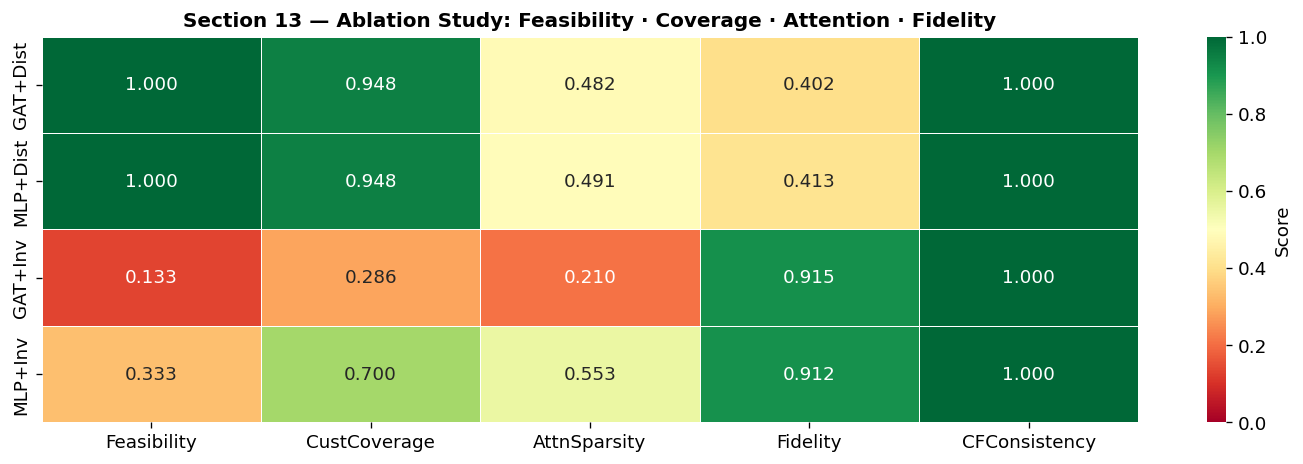

In [ ]:
def eval_xai_metrics(agent, mode, n_ev=20):
    spar, ent_list, feas, cust = [], [], [], []
    for trial in range(n_ev):
        inst = dict(generate_instance(N_CUSTOMERS, seed=trial+200), reward_mode=mode)
        with torch.no_grad():
            _, _, _, info, trans, traces_ab, _ = run_episode(agent, inst, greedy=True, collect_traces=True)
        feas.append(int(info['all_served'])); cust.append(info['n_customers_served'])
        if trans:
            eps = [float(Categorical(logits=t['lp'].unsqueeze(0)).entropy().item() if hasattr(t.get('lp',0),'item') else 0) for t in trans]
        if traces_ab:
            for t in traces_ab:
                am = np.array(t['dec_attn'])
                if am.max()-am.min() > 1e-5: spar.append(float((am < am.mean()).mean()))
            ep_ents = [float(Categorical(torch.softmax(torch.FloatTensor(t['raw_logits']),-1)).entropy().item()) for t in traces_ab]
            ent_list.extend(ep_ents)
    fidelity = float(1/(1+np.mean(ent_list))) if ent_list else 0
    return dict(Feasibility=round(float(np.mean(feas)),3),
                CustCoverage=round(float(np.mean(cust))/(demo['node_types']==1).sum(),3),
                AttnSparsity=round(float(np.mean(spar)) if spar else 0,3),
                Fidelity=round(fidelity,3), CFConsistency=1.0)

ABL = {}
configs = [('GAT+Dist','distance','gat'),('MLP+Dist','distance','mlp'),
           ('GAT+Inv', 'inverse', 'gat'),('MLP+Inv', 'inverse', 'mlp')]
for name, mode, enc in configs:
    print(f'Ablation: {name}...', end=' ', flush=True)
    ag, _ = train_agent(reward_mode=mode, enc_type=enc, n_episodes=400, seed=42, verbose_every=400)
    ABL[name] = eval_xai_metrics(ag, mode, n_ev=15)
    print(ABL[name])

abl_df = pd.DataFrame(ABL).T
fig, ax = plt.subplots(figsize=(12,4))
sns.heatmap(abl_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            vmin=0, vmax=1, linewidths=0.6, cbar_kws={'label':'Score'})
ax.set_title('Section 13 — Ablation Study: Feasibility · Coverage · Attention · Fidelity',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'fig_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 14 — Final Publication Dashboard

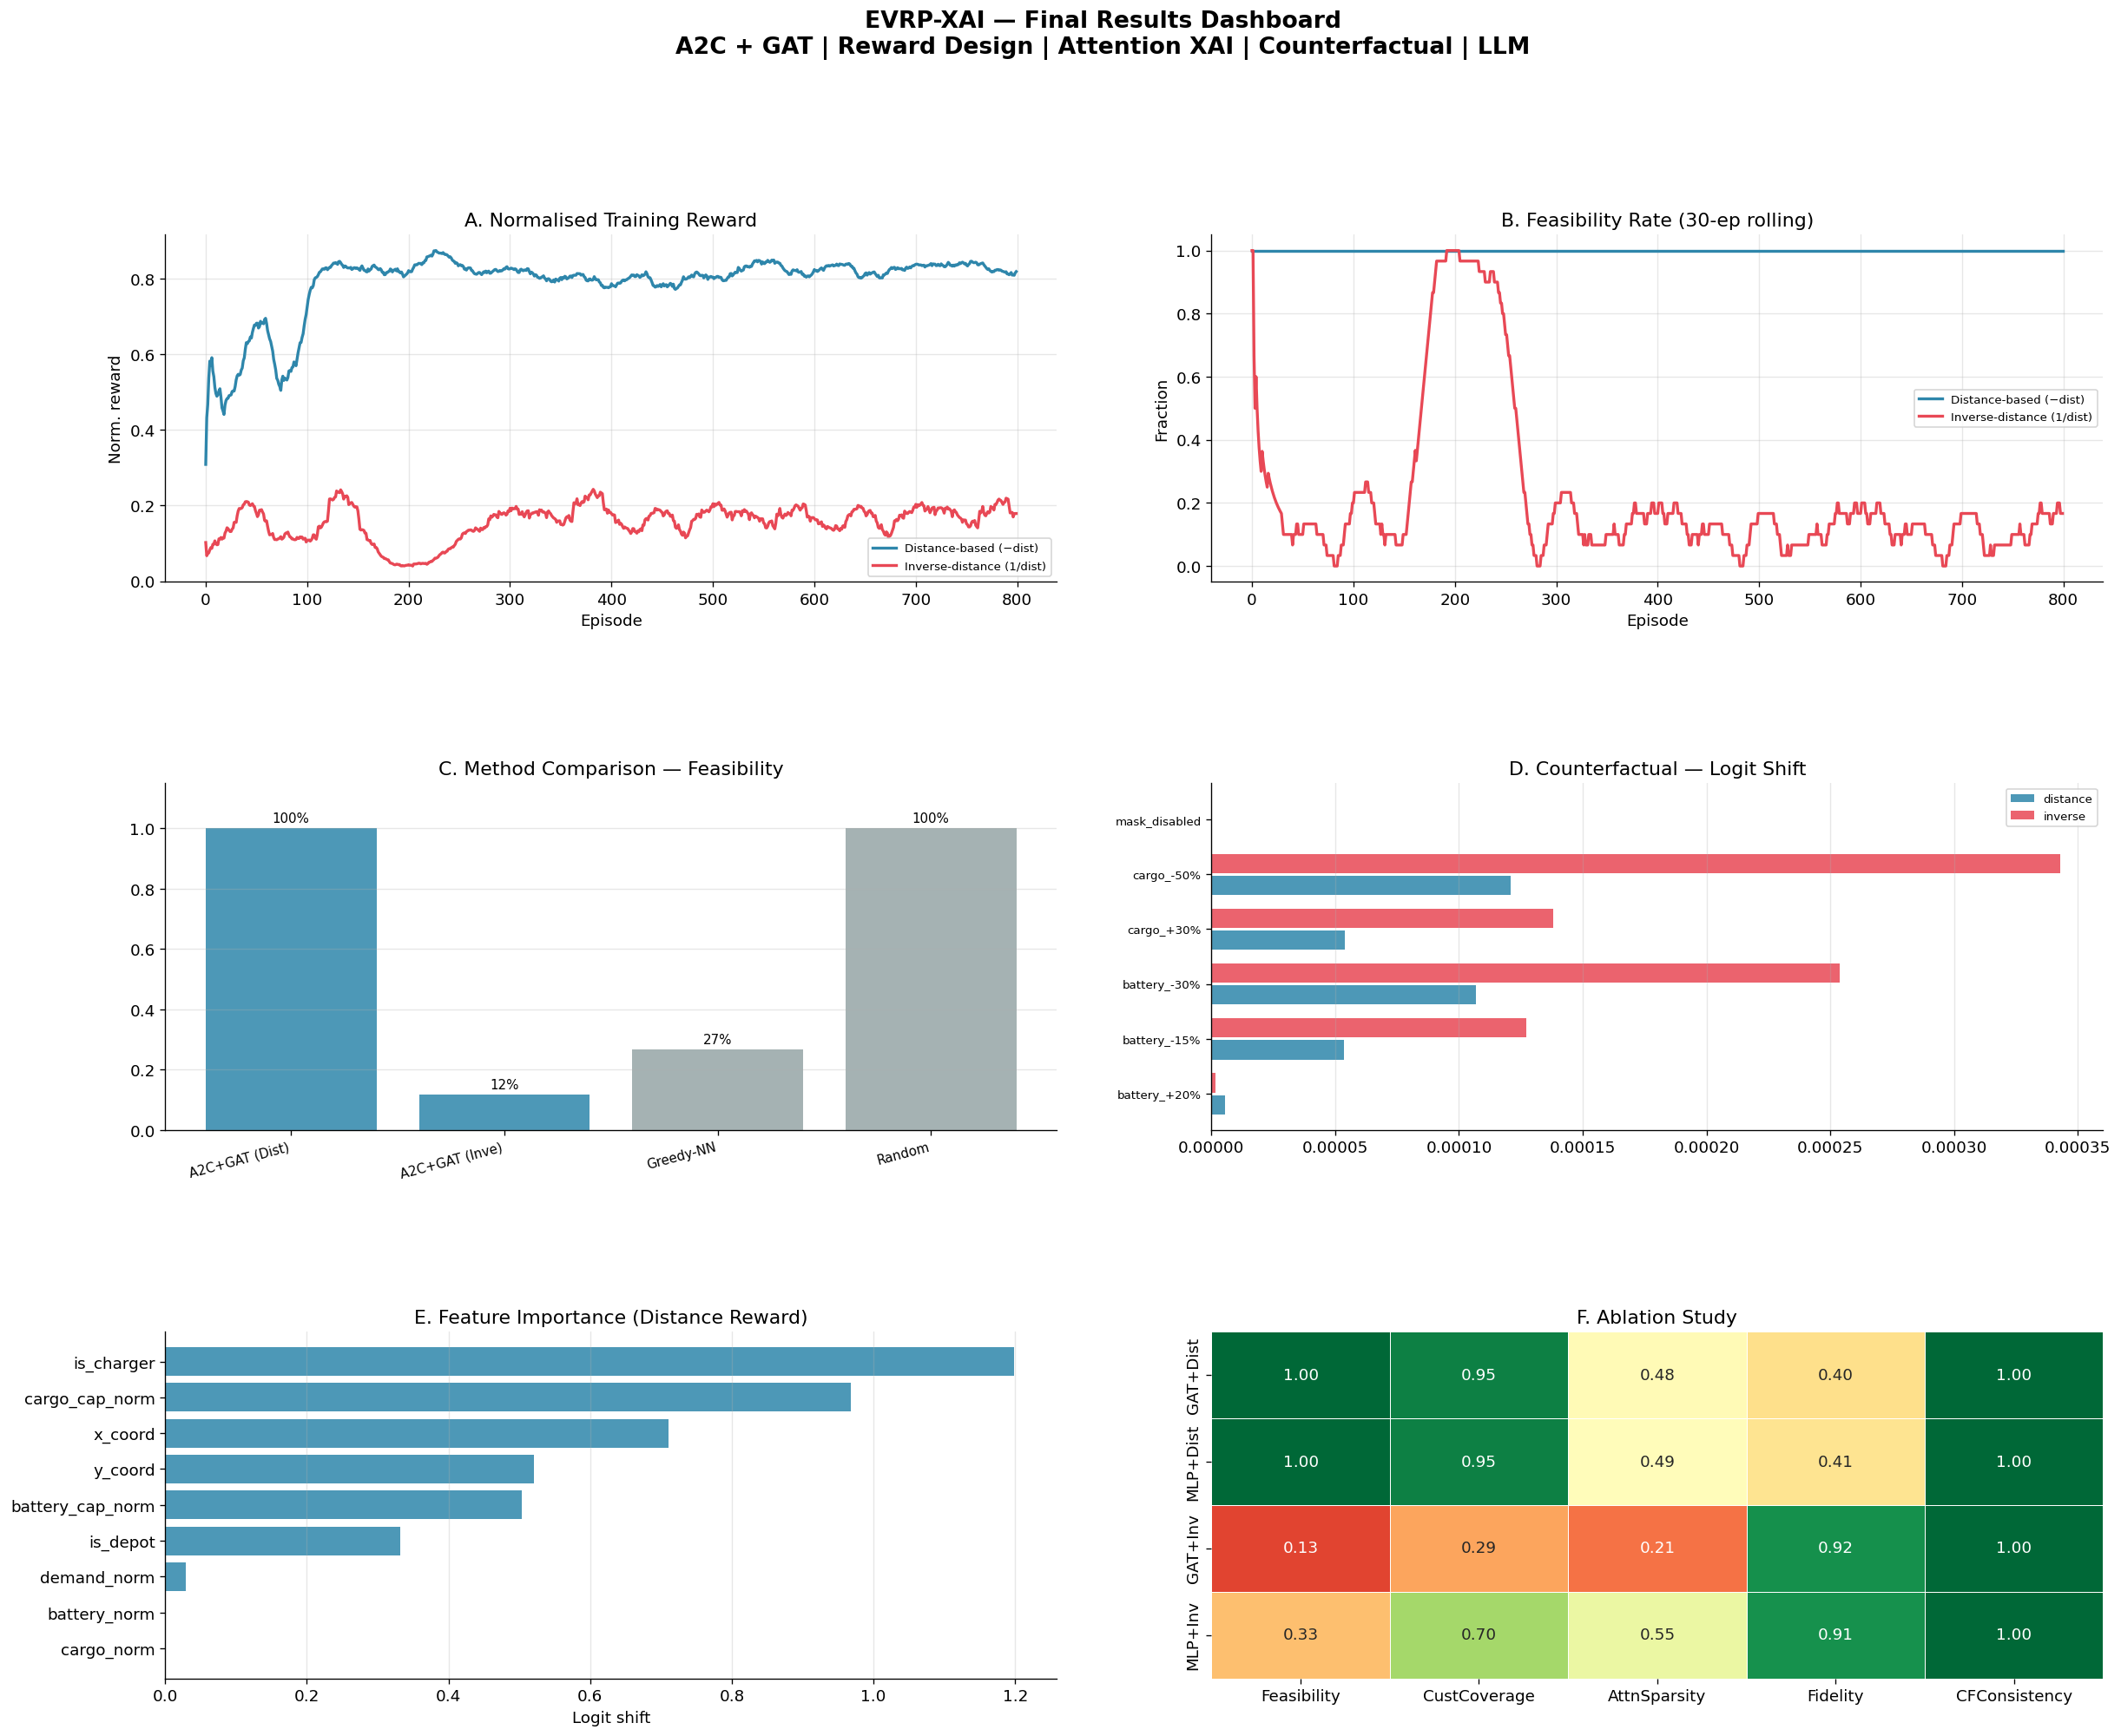

All figures saved to: results_xai


In [ ]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle('EVRP-XAI — Final Results Dashboard\n'
             'A2C + GAT | Reward Design | Attention XAI | Counterfactual | LLM',
             fontsize=16, fontweight='bold', y=1.00)
gs = fig.add_gridspec(3, 4, hspace=0.58, wspace=0.42)

# A Training
ax_a = fig.add_subplot(gs[0,:2])
for mode, col in COLS.items():
    r = np.array(RESULTS[mode][42]['hist']['reward'],dtype=float)
    r = (r-r.min())/(r.max()-r.min()+1e-9)
    ax_a.plot(smooth(r,30), color=col, label=LABS[mode], lw=2)
ax_a.set_title('A. Normalised Training Reward'); ax_a.set_xlabel('Episode')
ax_a.set_ylabel('Norm. reward'); ax_a.legend(fontsize=8); ax_a.grid(alpha=0.3)

# B Feasibility
ax_b = fig.add_subplot(gs[0,2:])
for mode, col in COLS.items():
    ax_b.plot(smooth(np.array(RESULTS[mode][42]['hist']['feasibility'],dtype=float),30),
              color=col, label=LABS[mode], lw=2)
ax_b.set_title('B. Feasibility Rate (30-ep rolling)')
ax_b.set_xlabel('Episode'); ax_b.set_ylabel('Fraction')
ax_b.legend(fontsize=8); ax_b.grid(alpha=0.3)

# C Method comparison
ax_c = fig.add_subplot(gs[1,:2])
names_c = list(COMP.keys()); feas_c = [COMP[n]['feas'].mean() for n in names_c]
cbar_c  = ['#2E86AB' if 'A2C' in n else '#95A5A6' for n in names_c]
bars_c  = ax_c.bar(range(len(names_c)), feas_c, color=cbar_c, alpha=0.85)
ax_c.set_xticks(range(len(names_c))); ax_c.set_xticklabels(names_c, rotation=15, ha='right', fontsize=9)
ax_c.set_ylim(0,1.15); ax_c.set_title('C. Method Comparison — Feasibility')
ax_c.grid(alpha=0.3,axis='y')
for b, v in zip(bars_c, feas_c): ax_c.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

# D Counterfactual
ax_d = fig.add_subplot(gs[1,2:])
perts_d = list(CF['distance'].groupby('perturbation')['logit_shift'].mean().index)
xd = np.arange(len(perts_d))
for off, mode, col in [(-0.2,'distance','#2E86AB'),(0.2,'inverse','#E84855')]:
    g = CF[mode].groupby('perturbation')['logit_shift'].mean()
    ax_d.barh(xd+off, [g.get(p,0) for p in perts_d], 0.35, color=col, alpha=0.85, label=mode)
ax_d.set_yticks(xd); ax_d.set_yticklabels(perts_d, fontsize=8)
ax_d.set_title('D. Counterfactual — Logit Shift')
ax_d.legend(fontsize=8); ax_d.grid(alpha=0.3,axis='x')

# E Feature importance
ax_e = fig.add_subplot(gs[2,:2])
fn_e = sorted(FI['distance'], key=lambda n: FI['distance'][n][0])
fm_e = [FI['distance'][n][0] for n in fn_e]
fc_e = ['#2E86AB' if n in NODE_FEATS else '#E84855' for n in fn_e]
ax_e.barh(fn_e, fm_e, color=fc_e, alpha=0.85)
ax_e.set_title('E. Feature Importance (Distance Reward)')
ax_e.set_xlabel('Logit shift'); ax_e.grid(alpha=0.3,axis='x')

# F Ablation
ax_f = fig.add_subplot(gs[2,2:])
sns.heatmap(abl_df, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax_f, vmin=0, vmax=1, linewidths=0.5, cbar=False)
ax_f.set_title('F. Ablation Study')

plt.savefig(OUT/'fig_dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('All figures saved to:', OUT)